In [19]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers, sweeney_simulate_kick, sweeney_kick_utils
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Data

In [29]:
pop = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/binaries", parts=[])
pop.bpp["row_num"] = np.arange(len(pop.bpp))
pop.colour = "tab:blue"
pop.label = "Fiducial"

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



In [ ]:
def load_data(filename, filter=True):
    '''Load Galaxia data into DataFrame'''
    data = ebf.read(filename, '/')
    centre = np.array(data['center'])
    keys = ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'age', 'smass', 'feh', 'popid']
    useful_data = []
    for key in keys:
        useful_data += [data[key]]
    useful_data = np.array(useful_data).T
    df = pd.DataFrame(useful_data, columns=keys)

    # Convert age to gigayears
    df['age'] = 10**df['age'] / 10**9

    # Make data centred on galactic centre
    df.loc[:, ['px', 'py', 'pz', 'vx', 'vy', 'vz']] += centre

    # Add rtype column which specifies remnant type
    rtype = []
    for mass in df['smass']:
        if mass > 25:
            rtype.append('Black Hole')
        elif mass > 8:
            rtype.append('Neutron Star')
        else:
            rtype.append('White Dwarf')
    df['rtype'] = rtype

    if filter:
        df = df[df['smass'] > 8]
    return df

In [ ]:
thing = load_data("/mnt/home/twagg/ceph/underworld/sweeney_data/galaxia_f1e-3_bhm2.35.ebf")

thing["comp"] = "thin"
thing.loc[thing.age.round(3) == 10.000, "comp"] = "bulge"
thing.loc[thing.age.round(3) == 11.000, "comp"] = "thick"
thing.loc[thing.age.round(3) == 13.000, "comp"] = "halo"

thing["R"] = np.sqrt(thing["px"]**2 + thing["py"]**2)

In [194]:
stars = load_data("/mnt/home/twagg/ceph/underworld/sweeney_data/milkyway_f1e-6.ebf", filter=False)
stars["R"] = np.sqrt(stars["px"]**2 + stars["py"]**2)

# Stuff

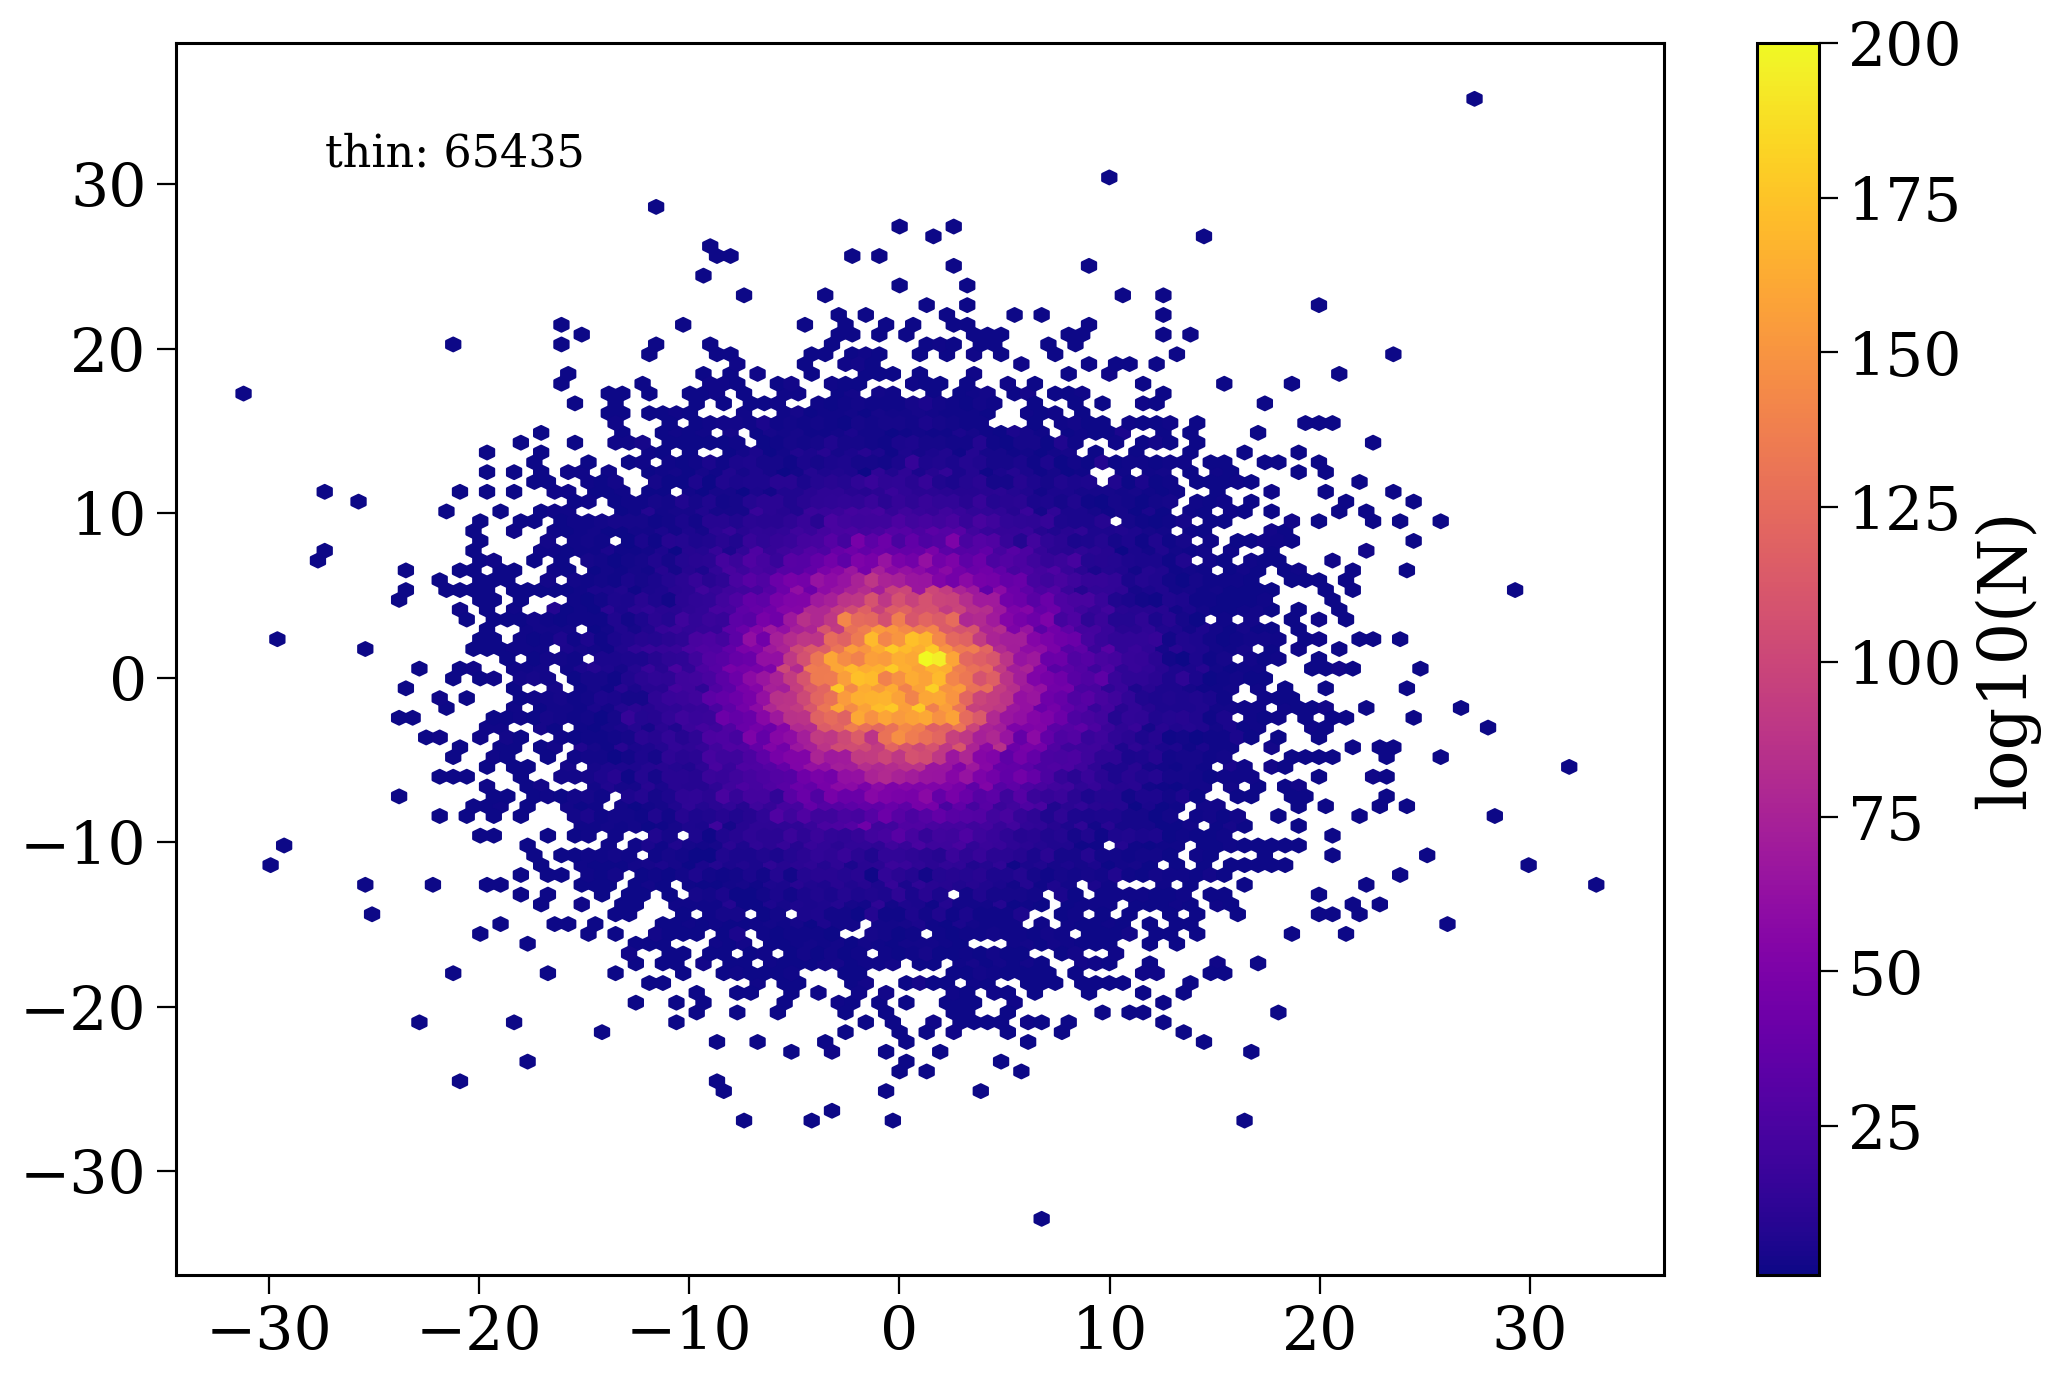

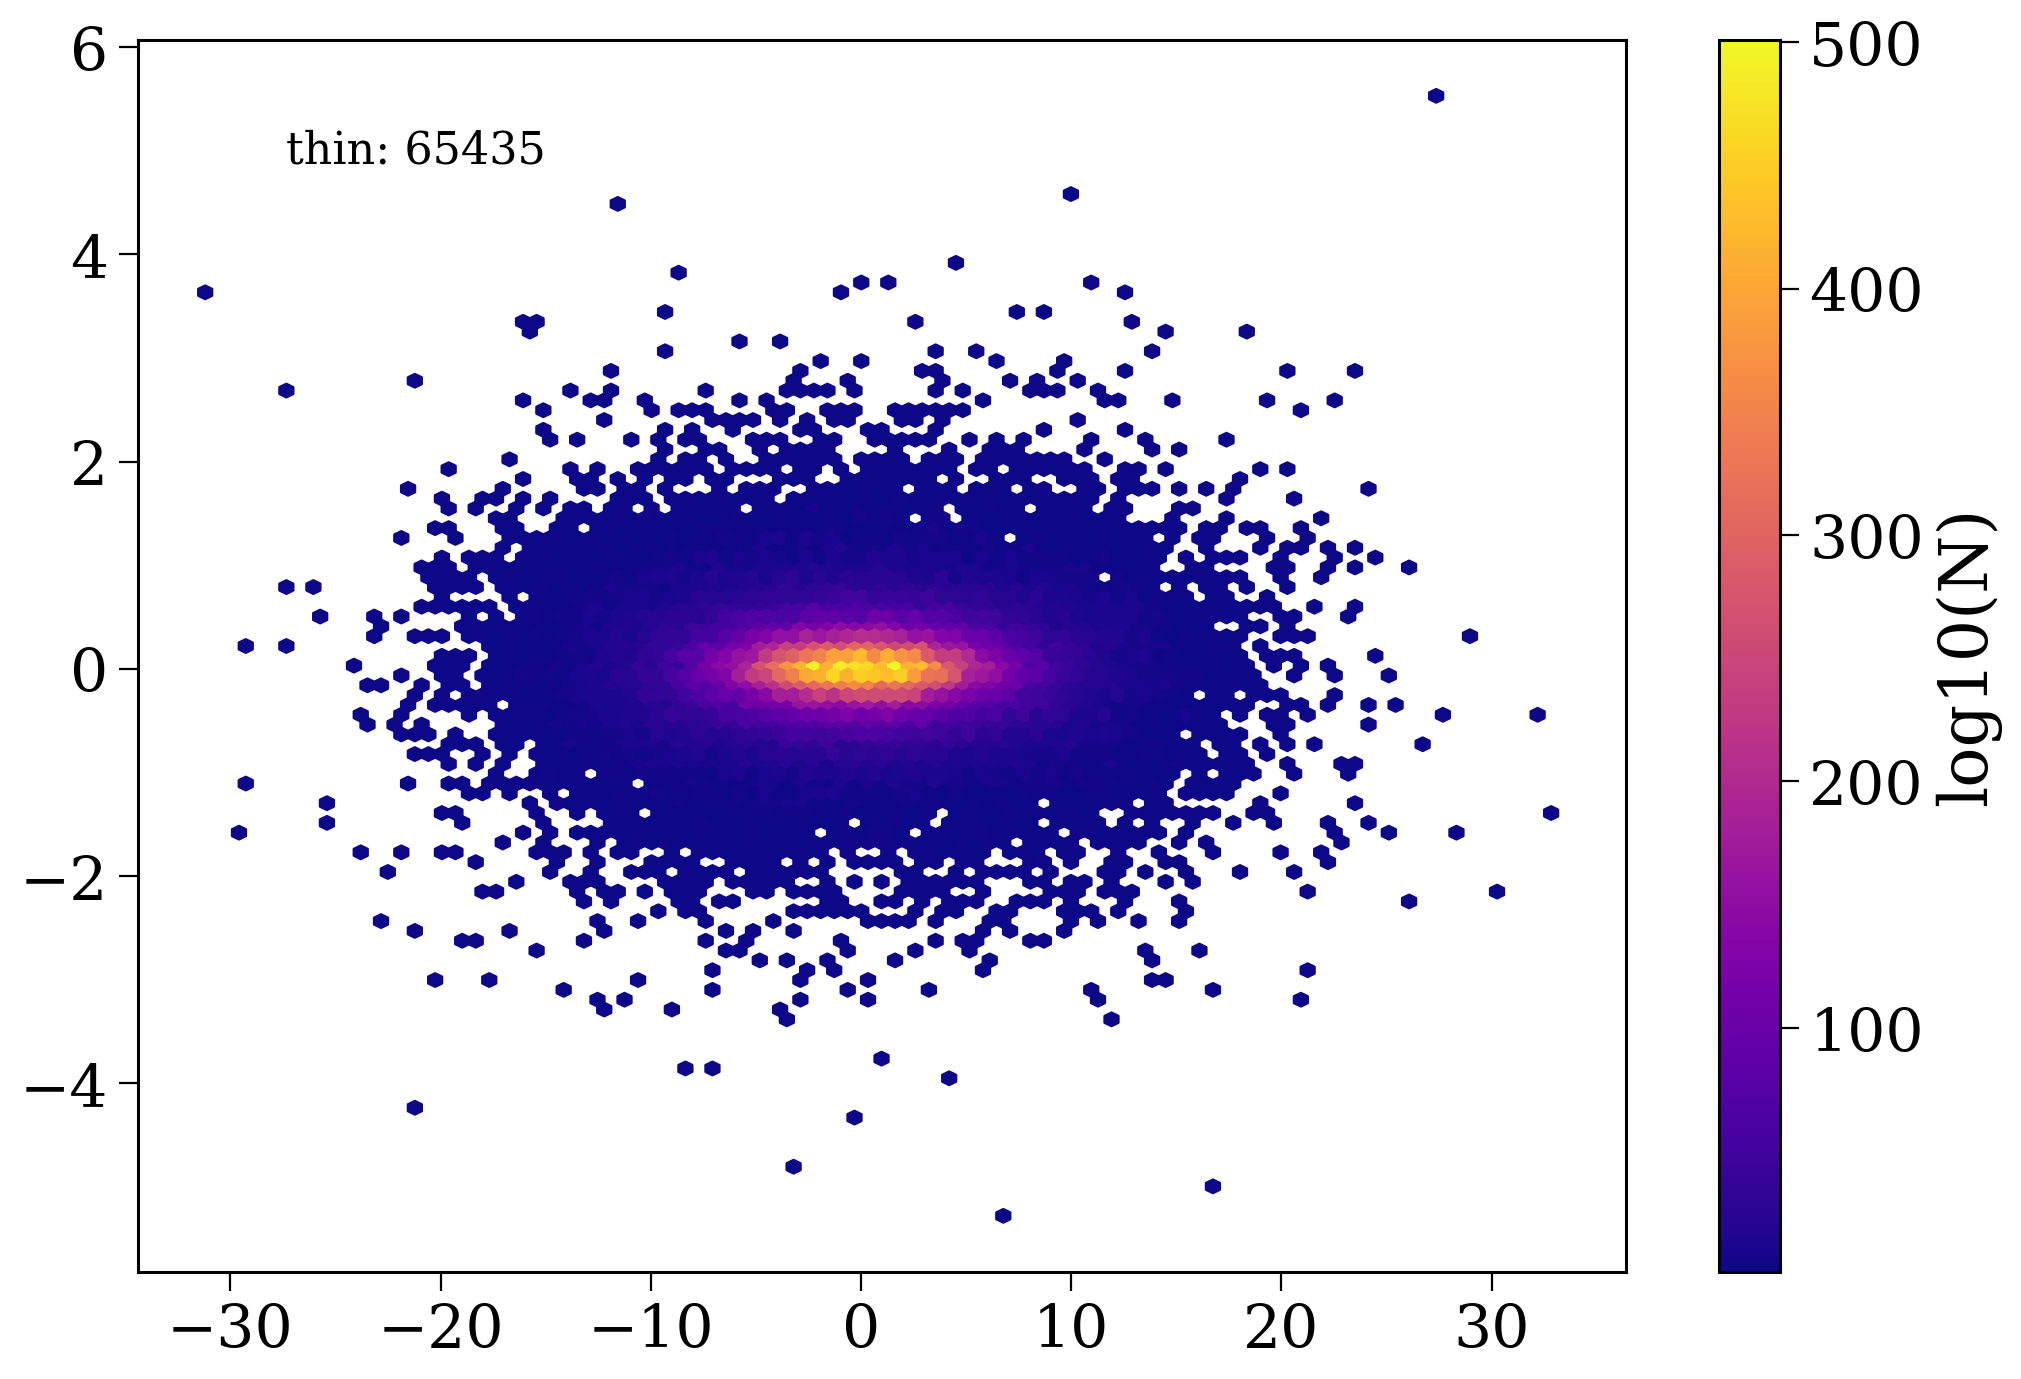

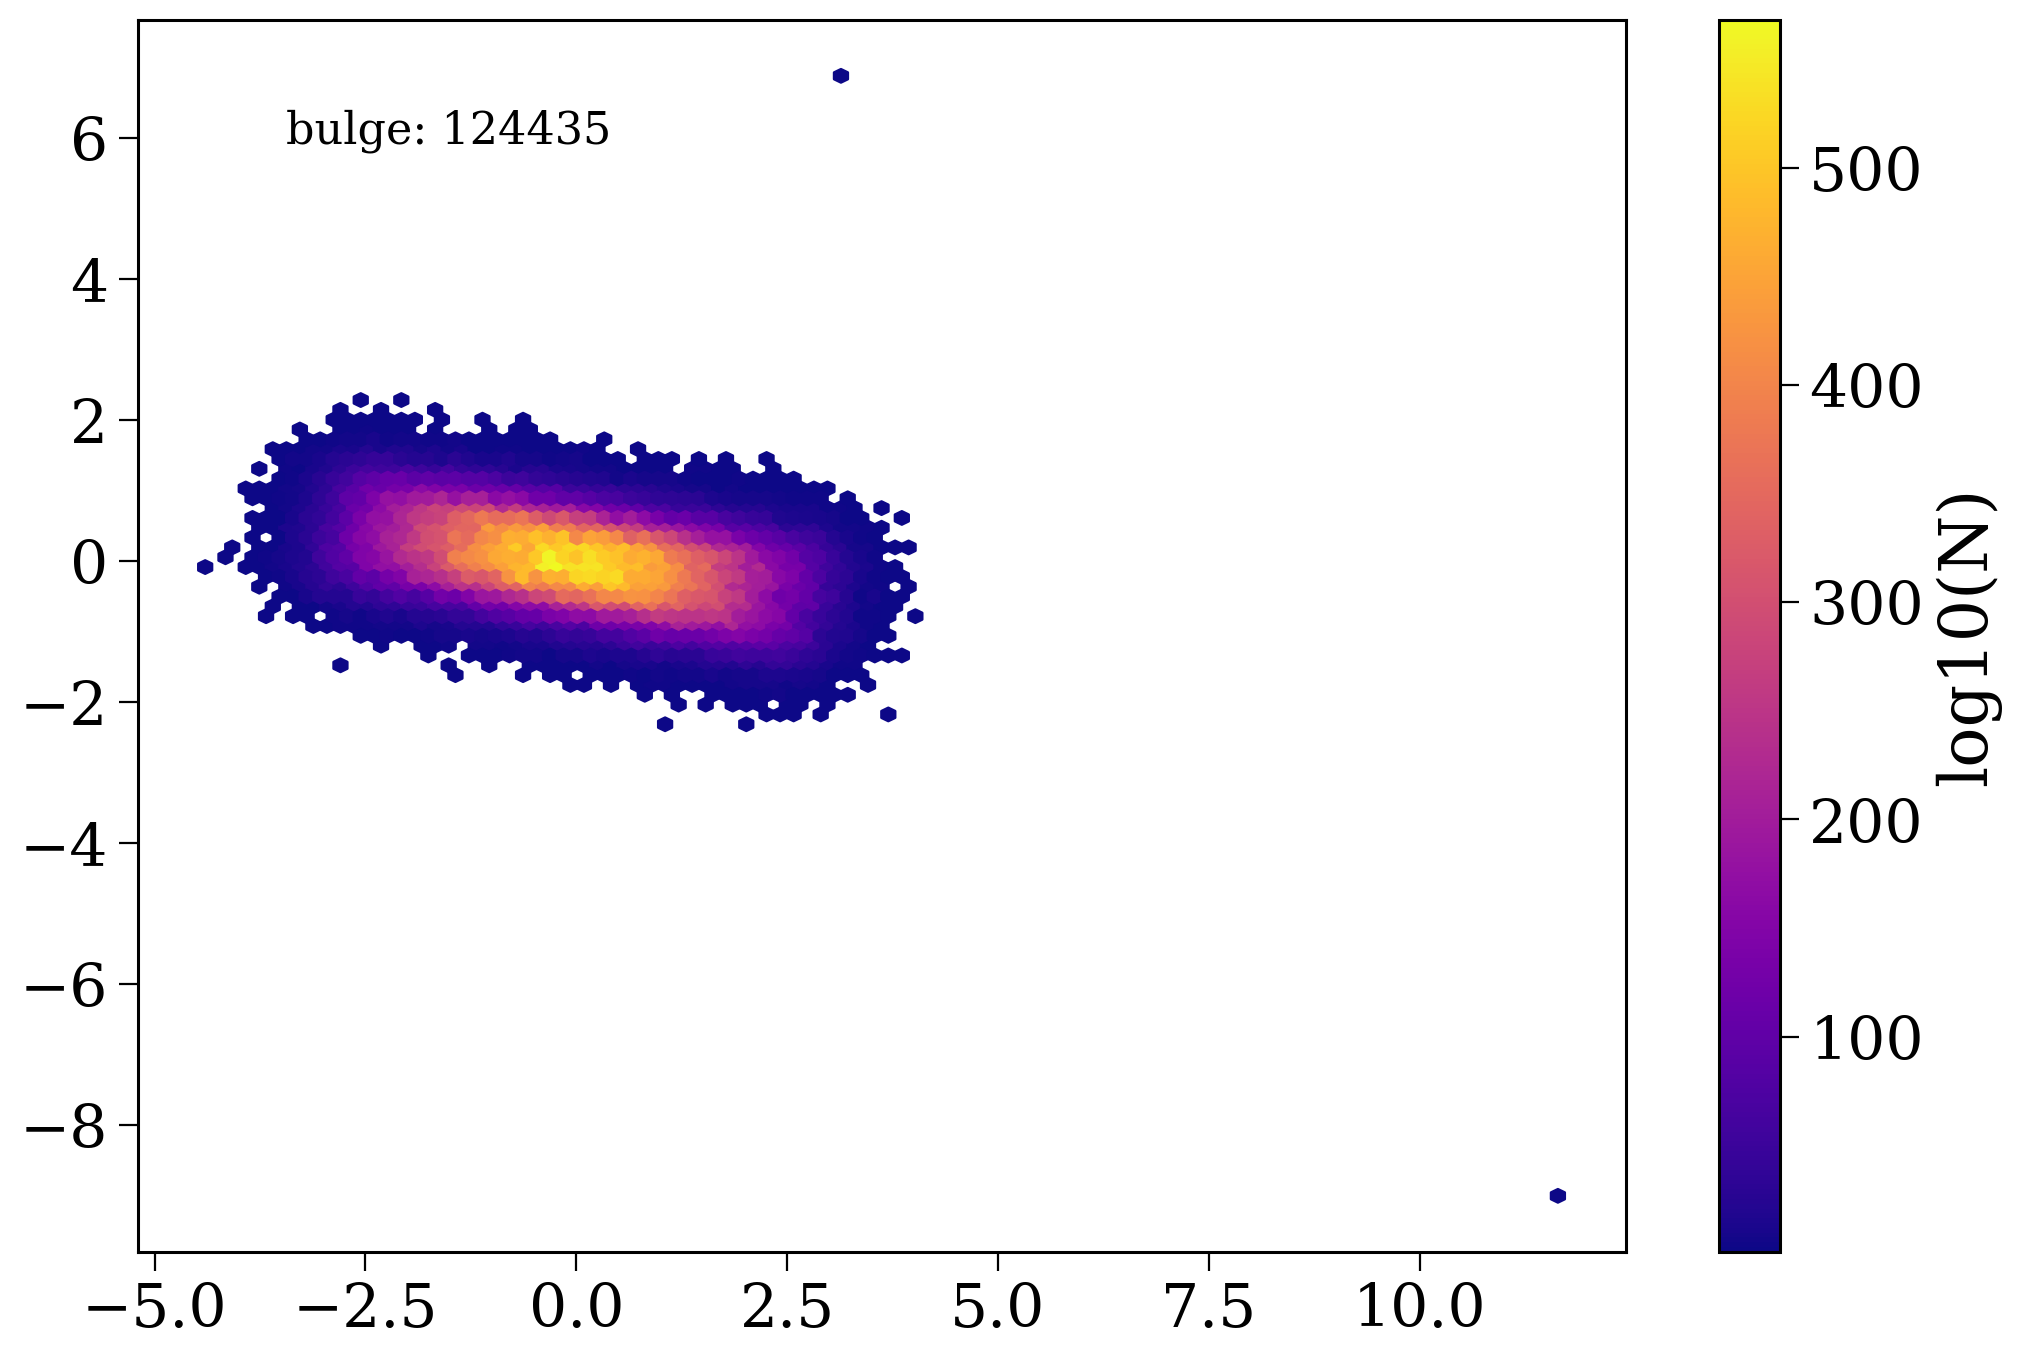

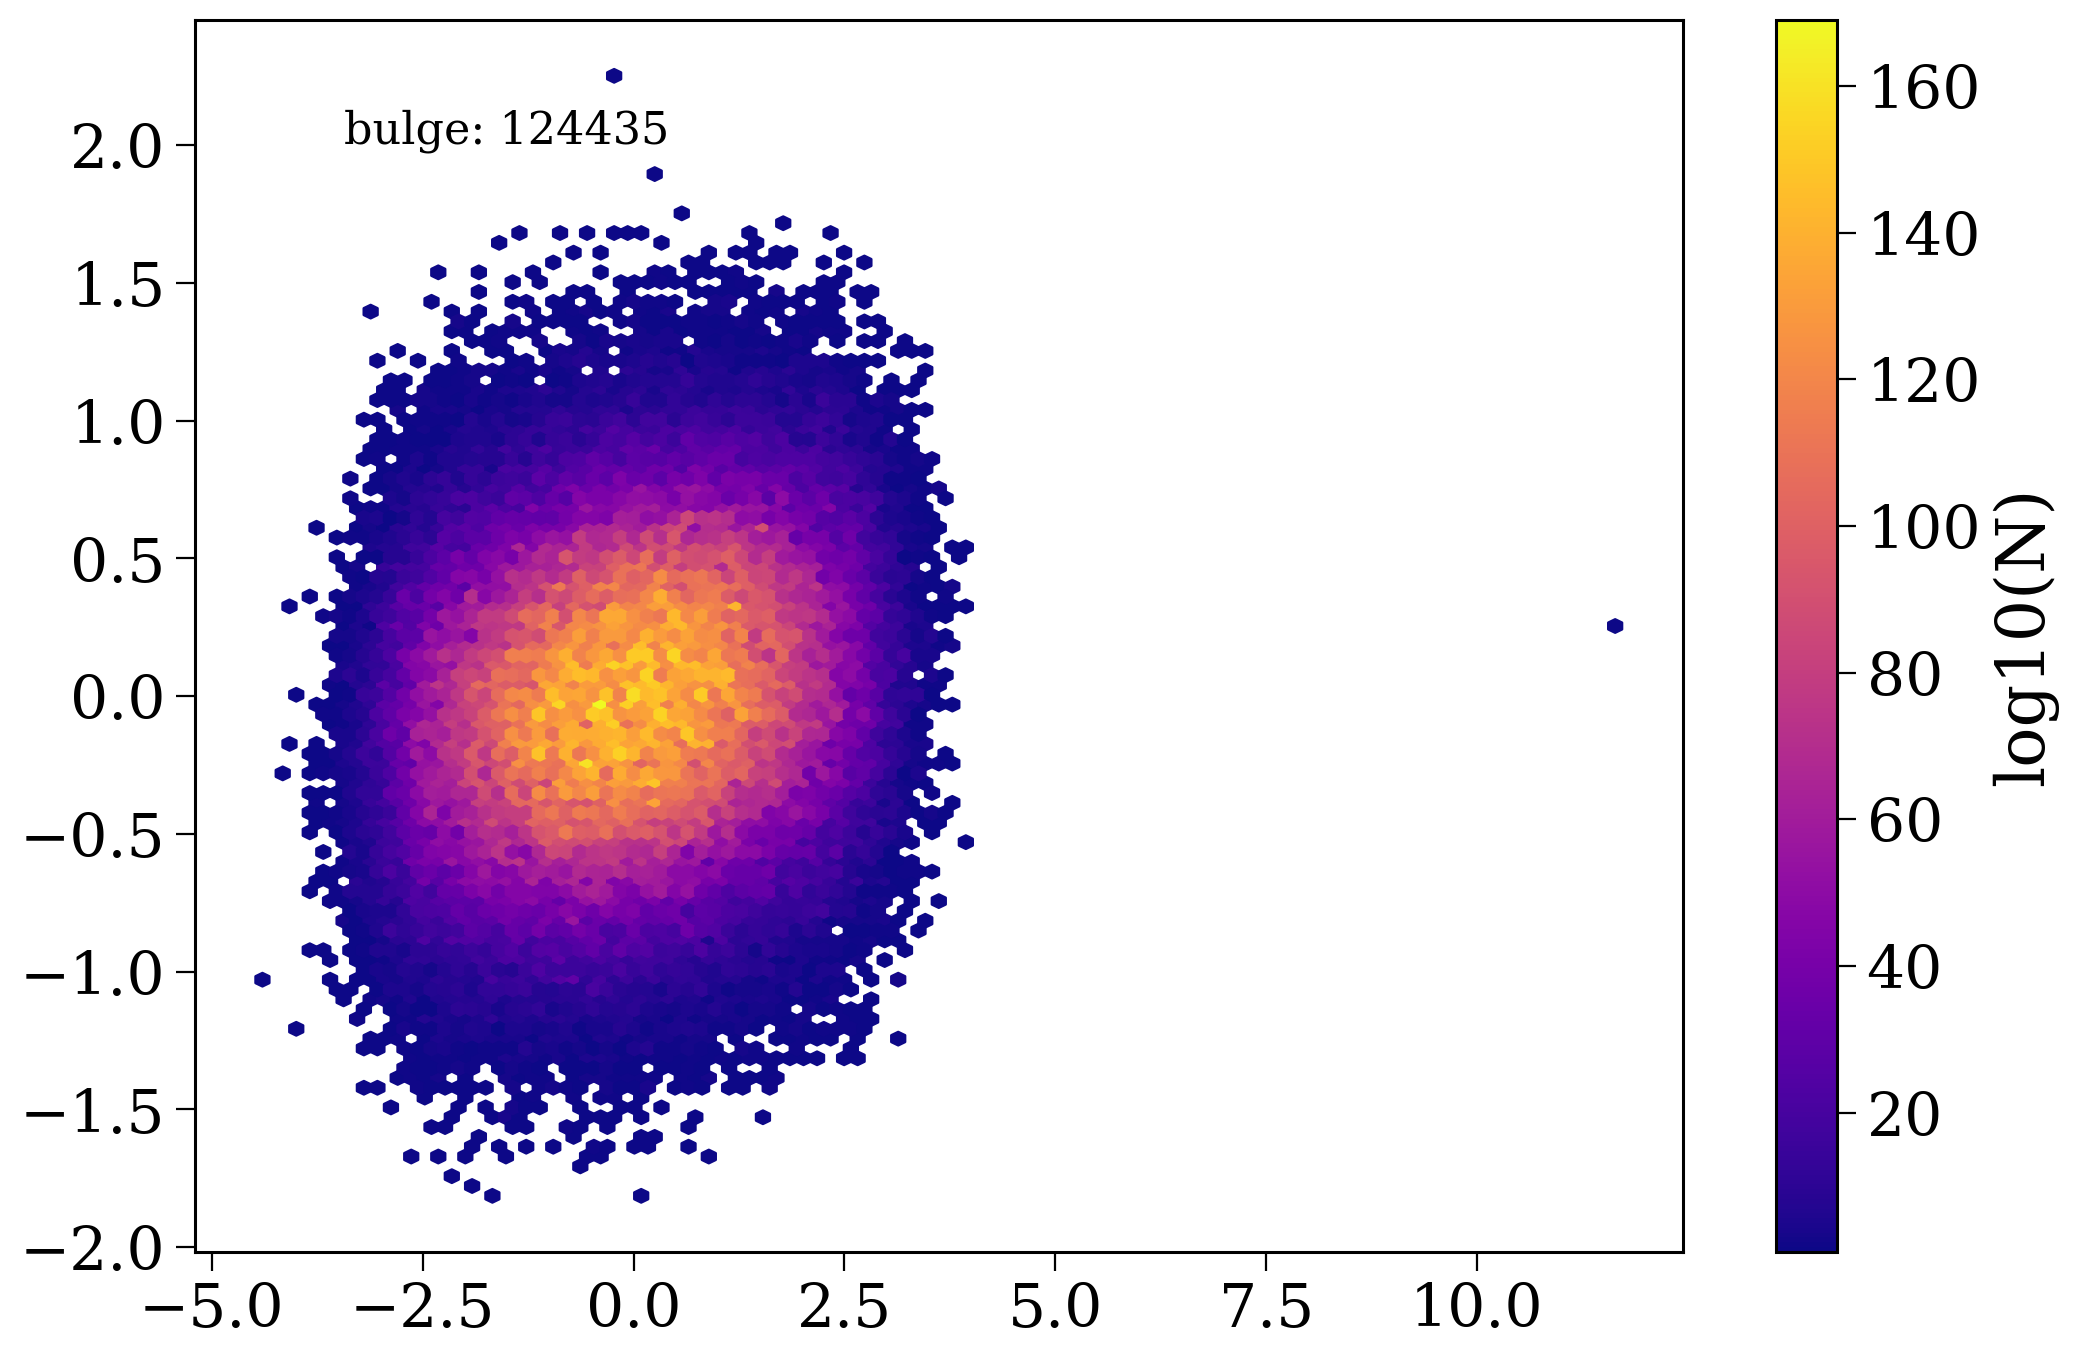

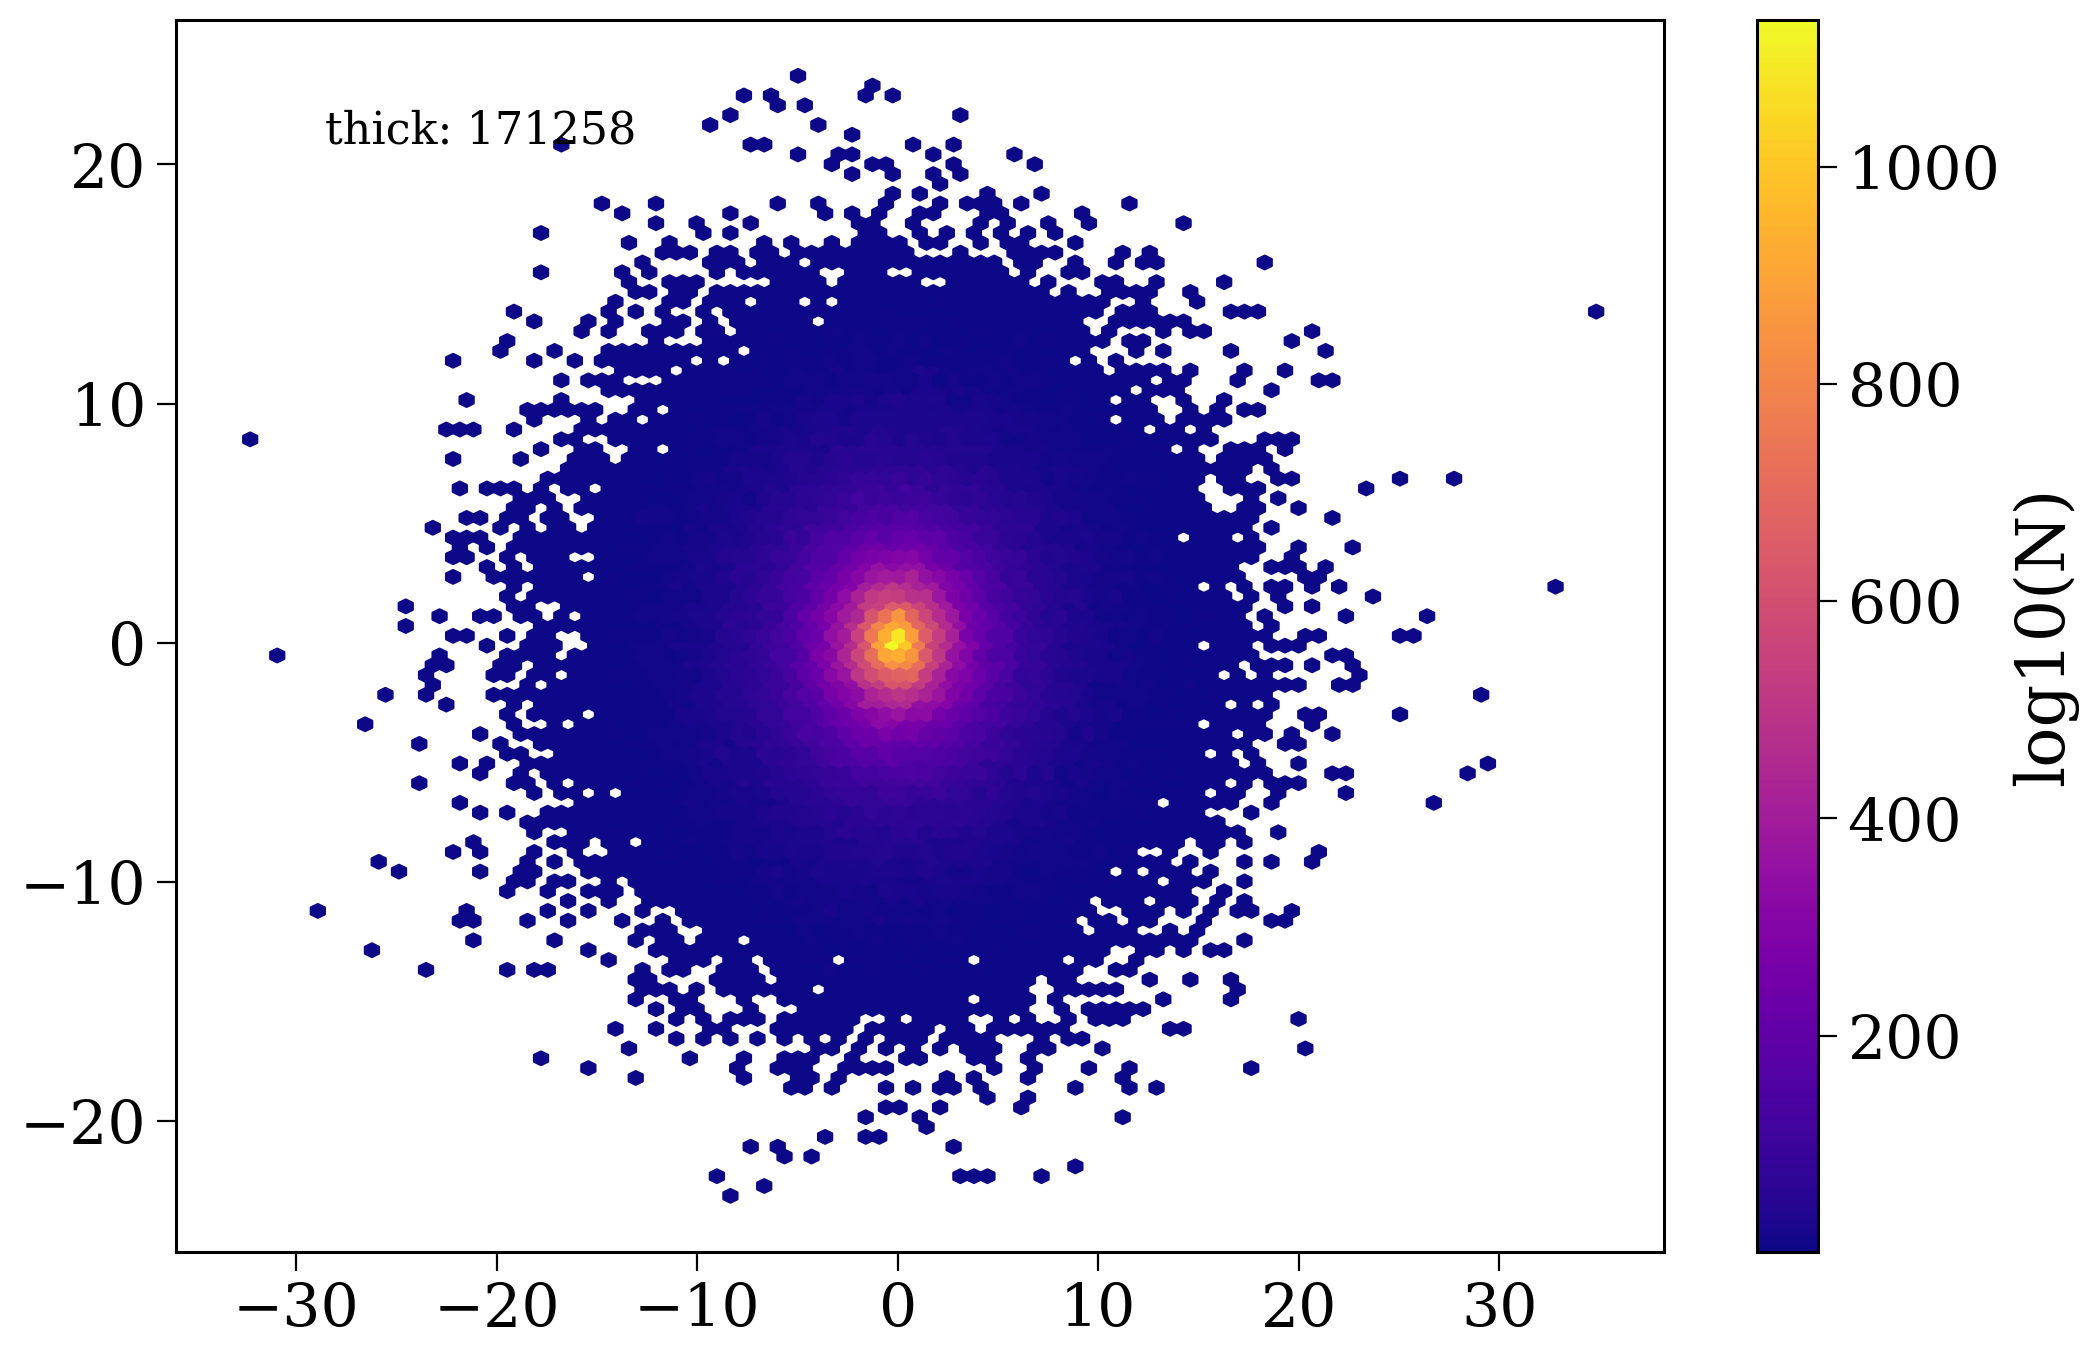

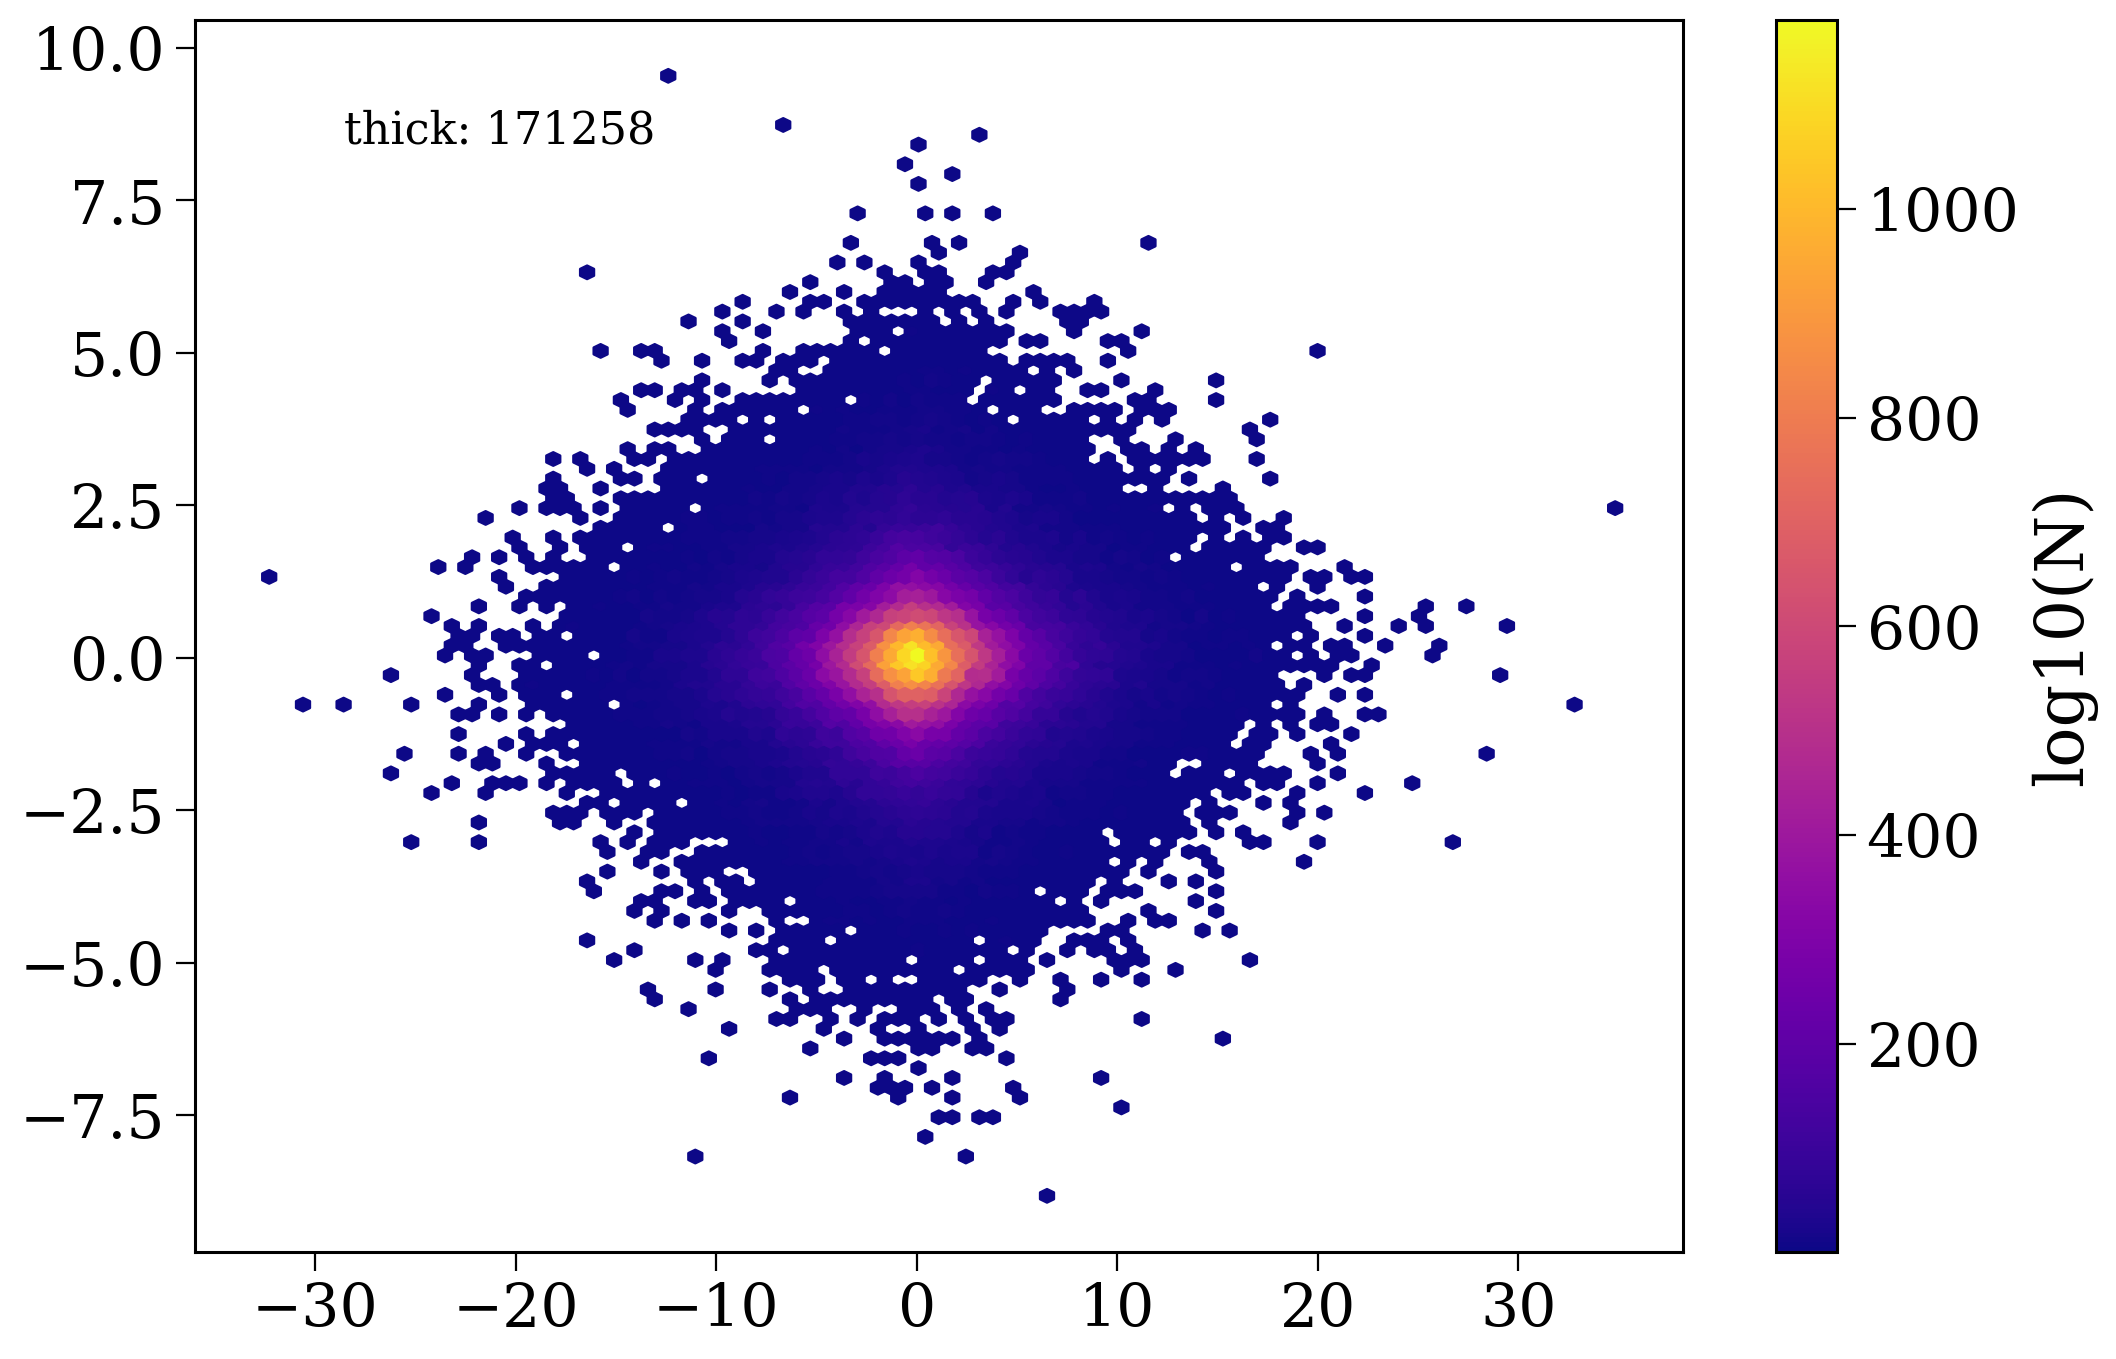

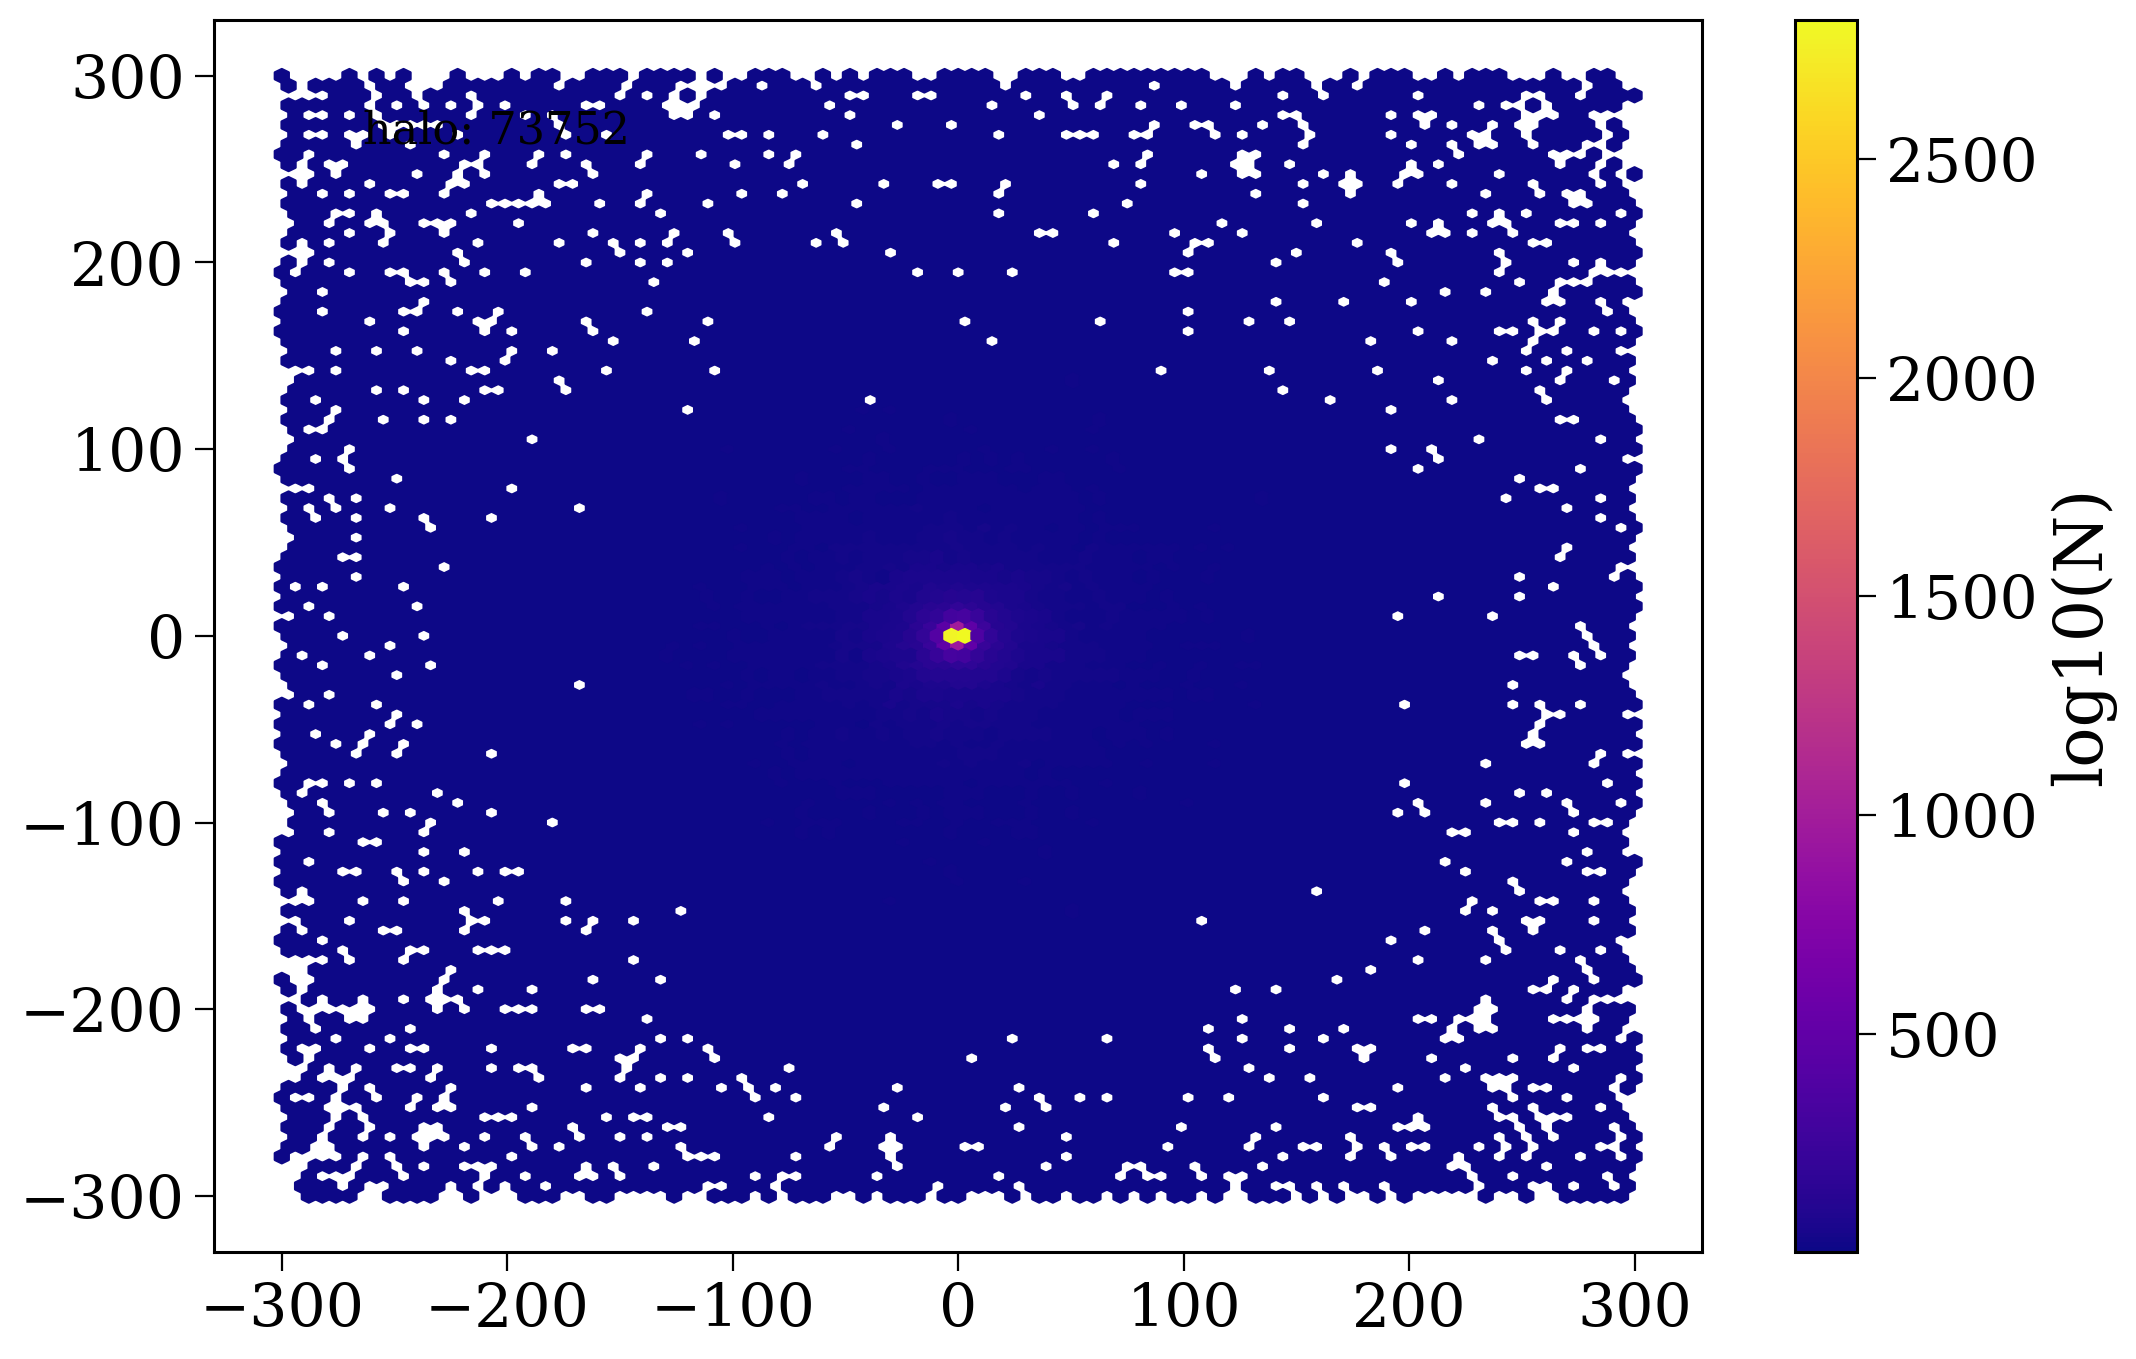

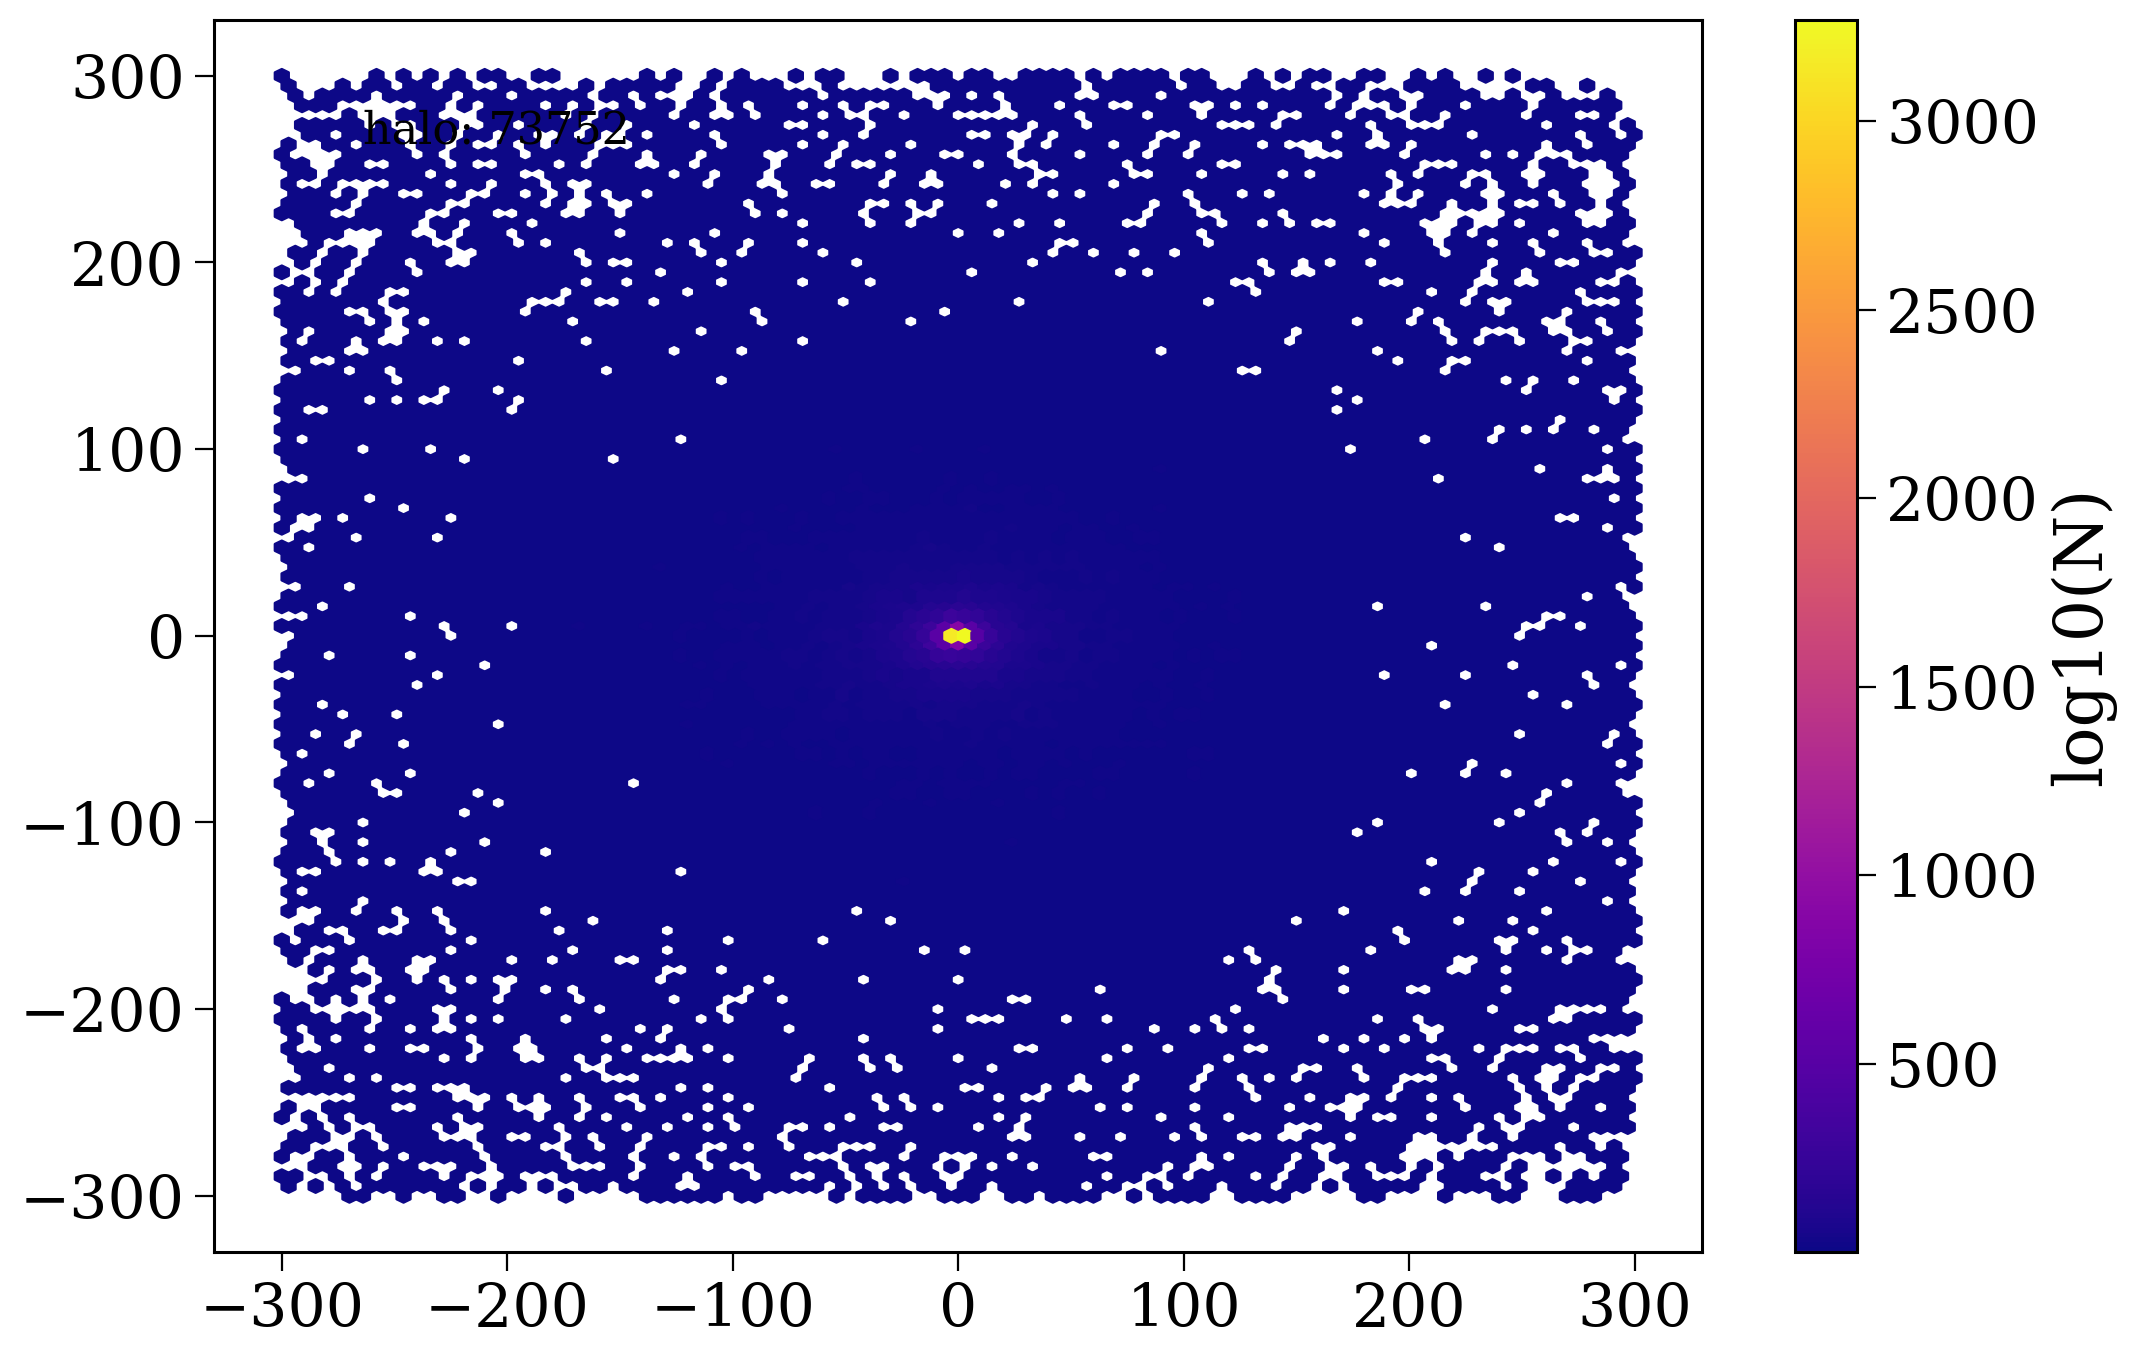

In [156]:
for comp in thing.comp.unique():
    hexbin = plt.hexbin(thing.px[thing.comp == comp], thing.py[thing.comp == comp], gridsize=100, cmap='plasma', mincnt=1)
    plt.colorbar(hexbin, label='log10(N)')
    plt.annotate(f"{comp}: {(thing.comp == comp).sum()}", xy=(0.1, 0.9), xycoords='axes fraction', fontsize=16)
    plt.show()
    hexbin = plt.hexbin(thing.px[thing.comp == comp], thing.pz[thing.comp == comp], gridsize=100, cmap='plasma', mincnt=1)
    plt.colorbar(hexbin, label='log10(N)')
    plt.annotate(f"{comp}: {(thing.comp == comp).sum()}", xy=(0.1, 0.9), xycoords='axes fraction', fontsize=16)
    plt.show()

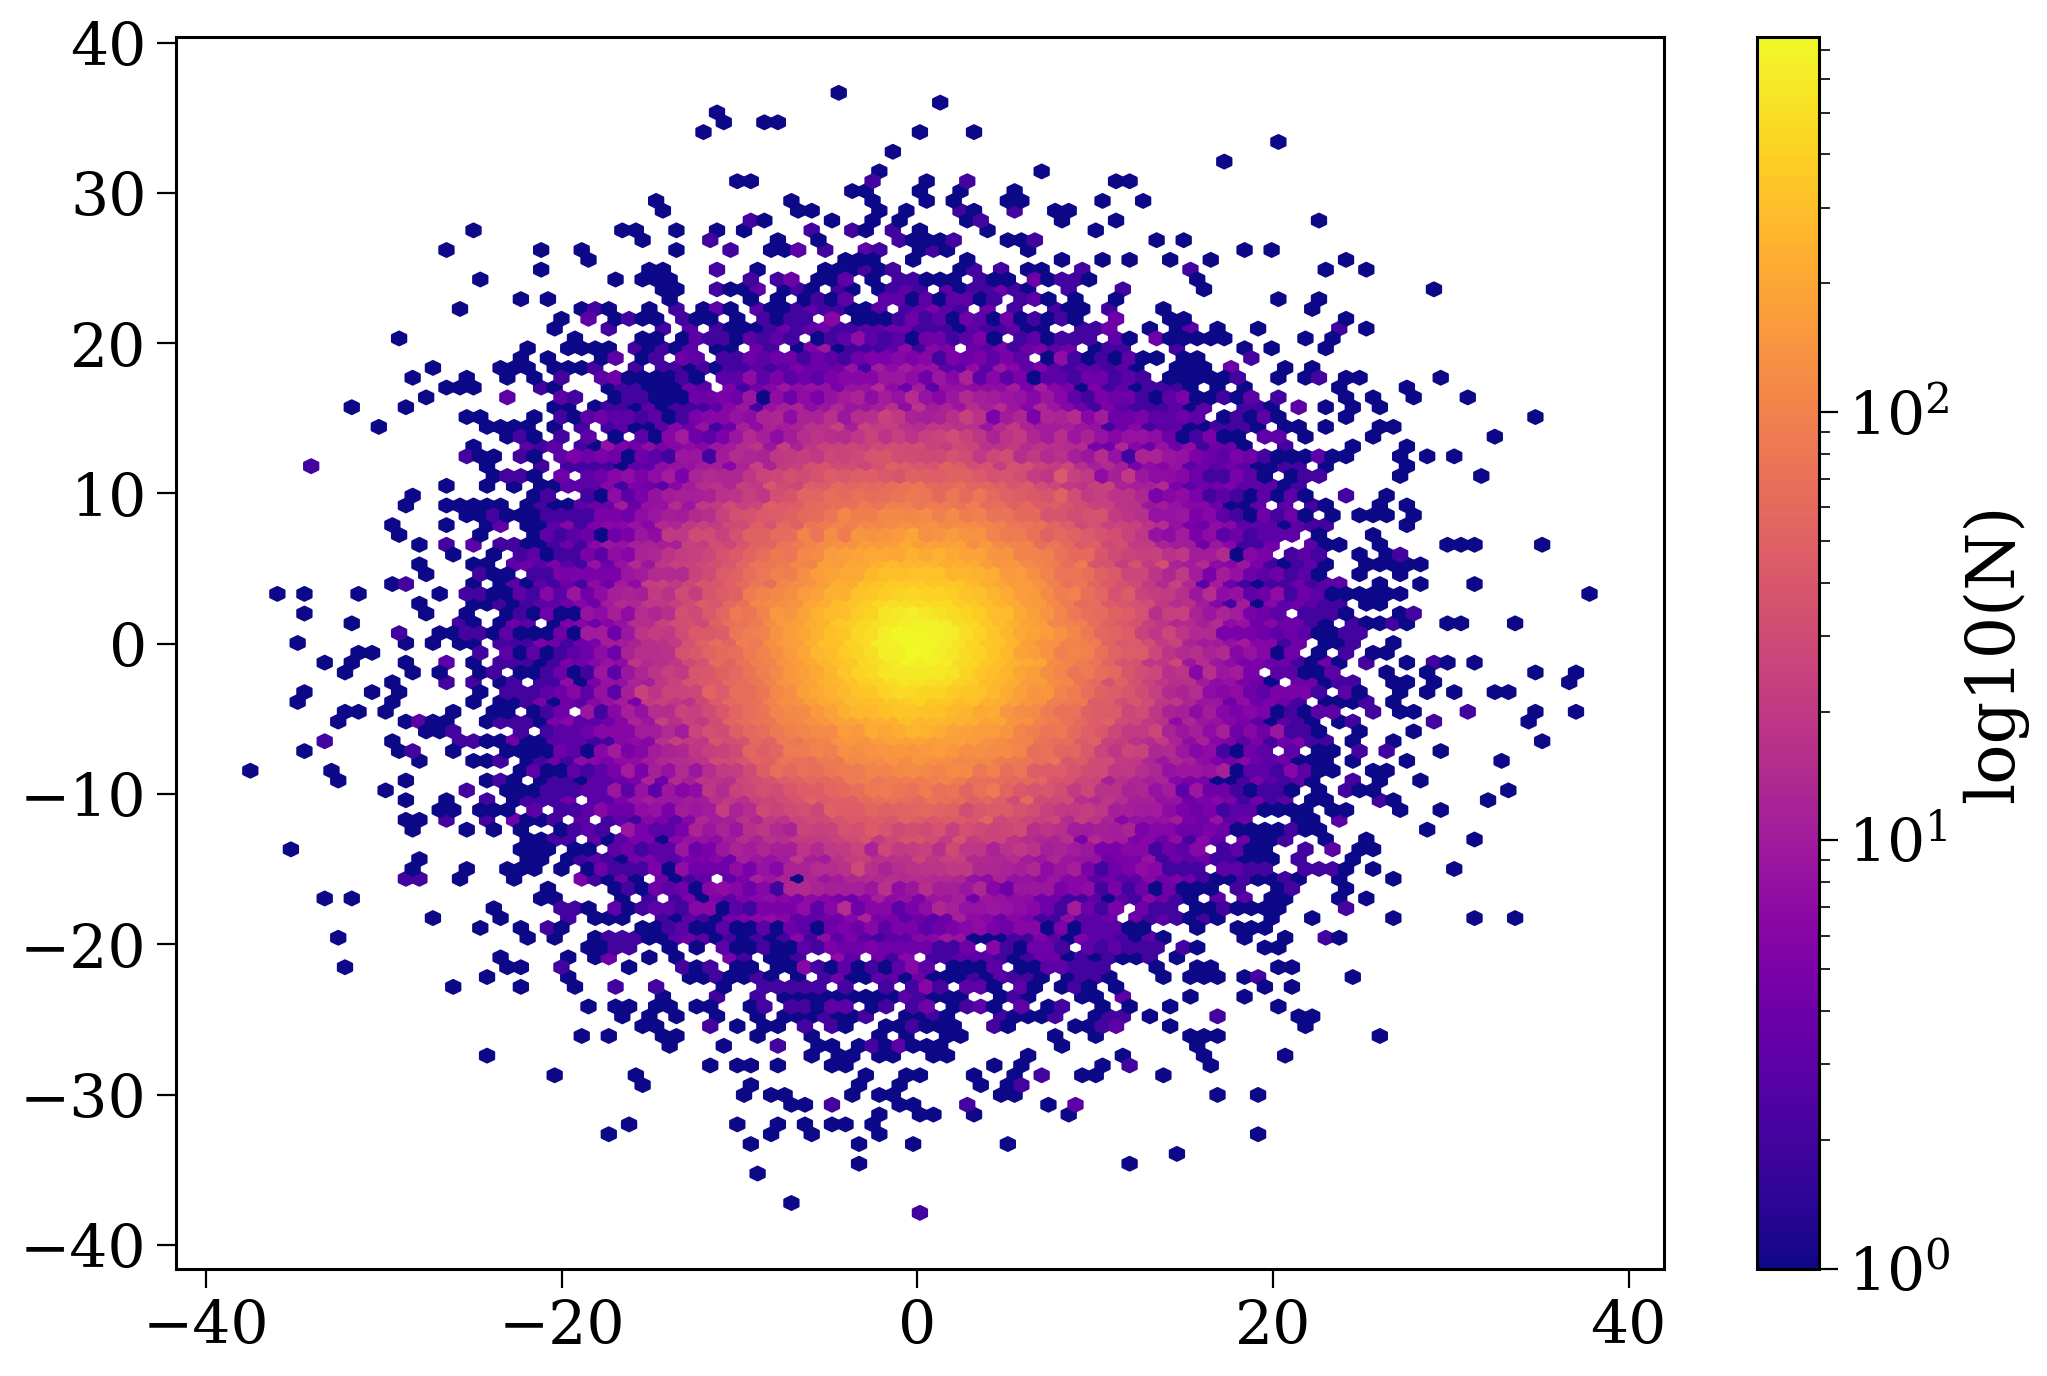

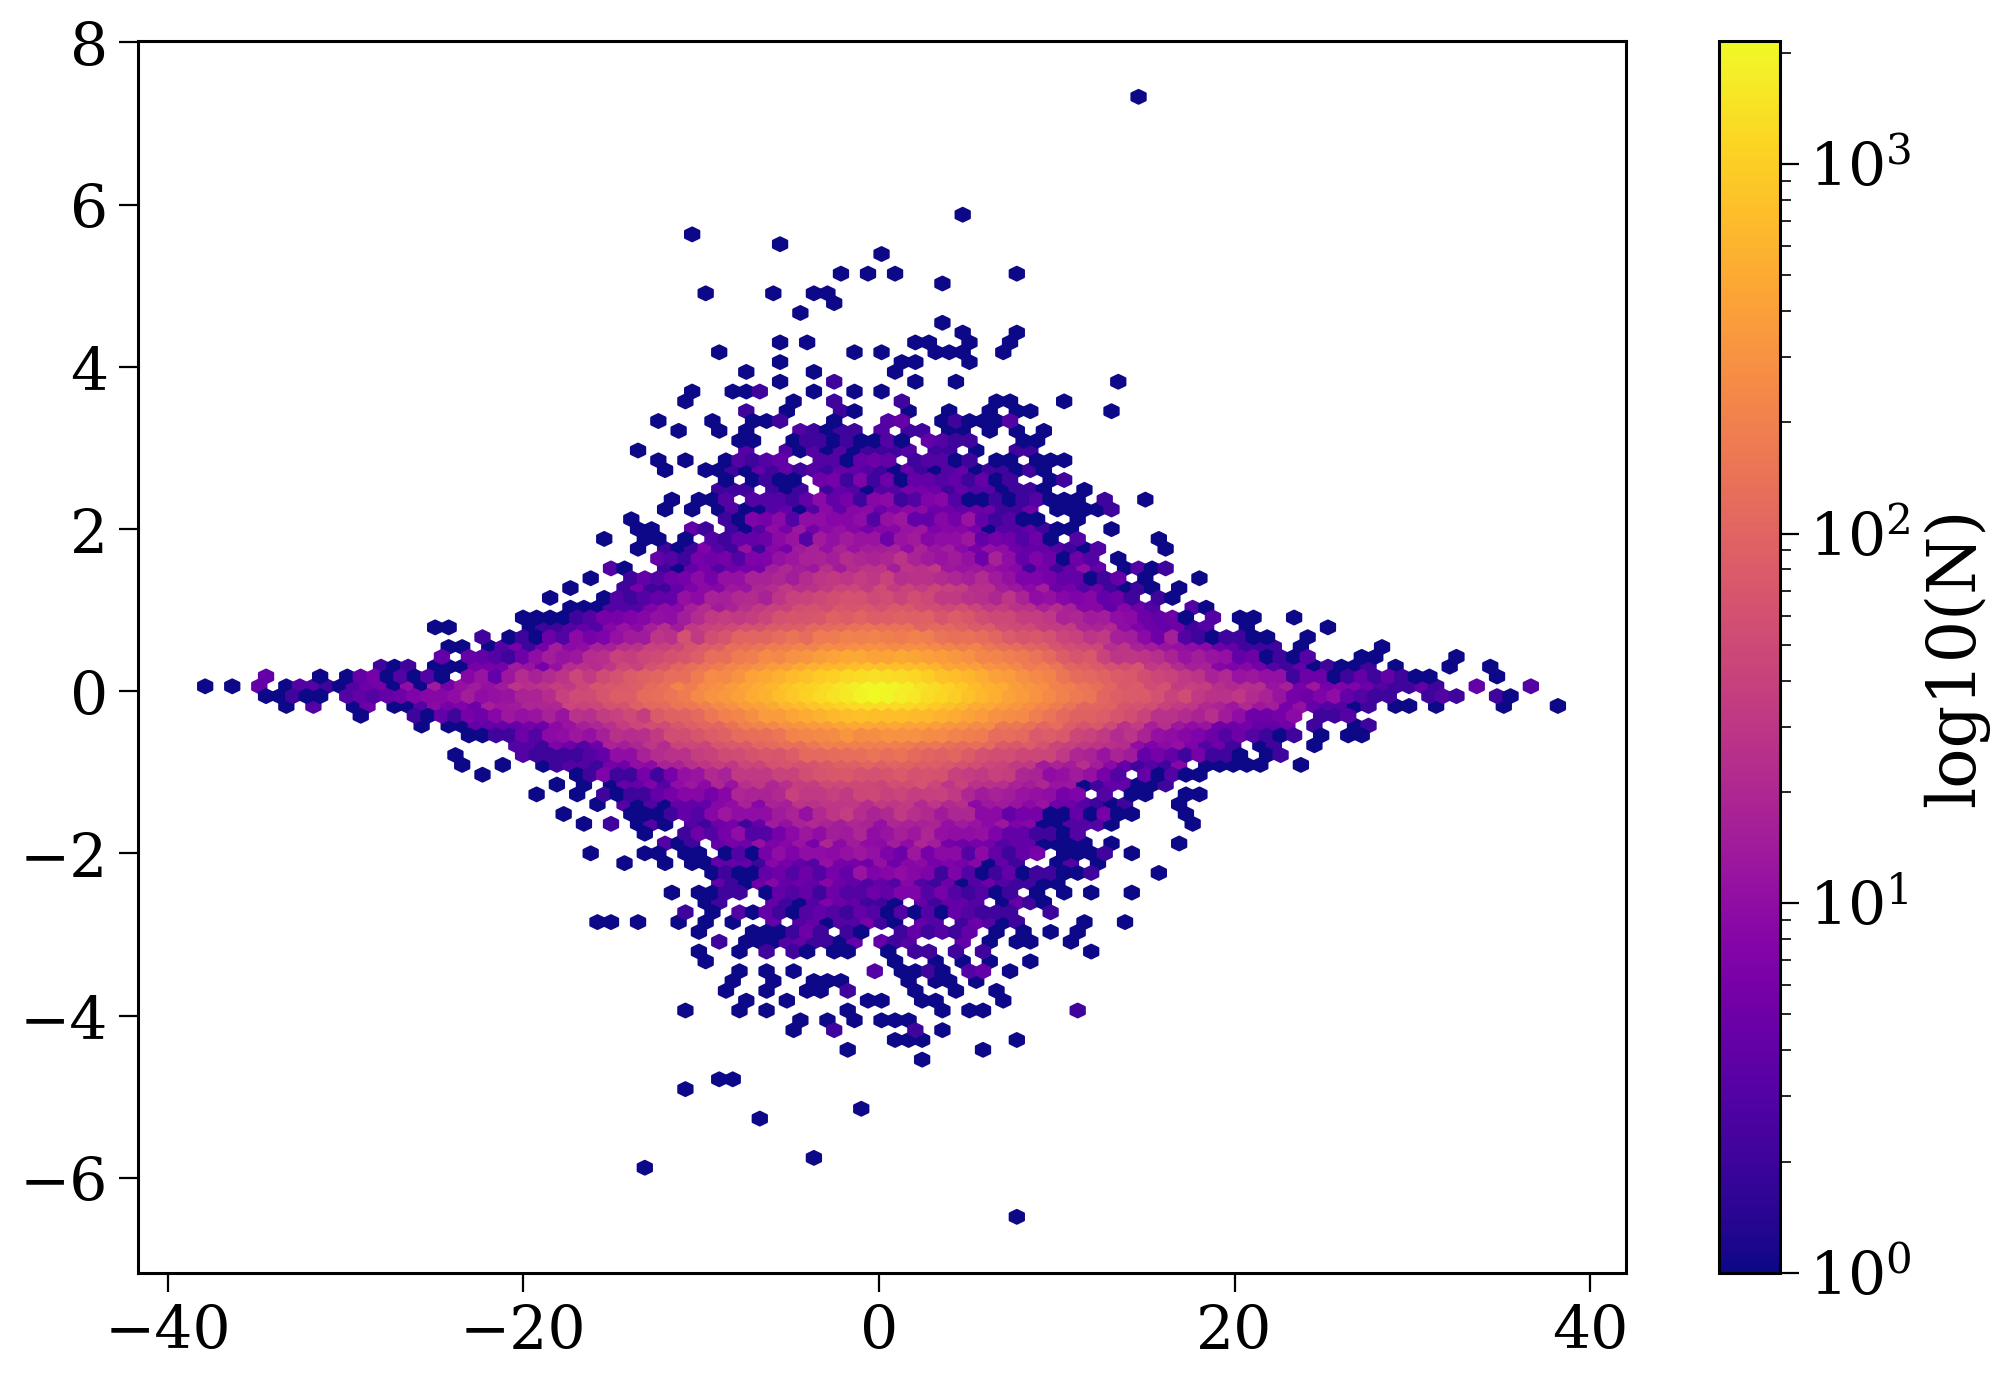

In [32]:
hexbin = plt.hexbin(pop.initial_galaxy.x, pop.initial_galaxy.y, gridsize=100, cmap='plasma', mincnt=1, bins="log")
plt.colorbar(hexbin, label='log10(N)')
plt.show()
hexbin = plt.hexbin(pop.initial_galaxy.x, pop.initial_galaxy.z, gridsize=100, cmap='plasma', mincnt=1, bins="log")
plt.colorbar(hexbin, label='log10(N)')
plt.show()

In [169]:
(pop.initial_galaxy.tau < 10 * u.Gyr).sum() / len(pop.initial_galaxy)

np.float64(0.7997116711938371)

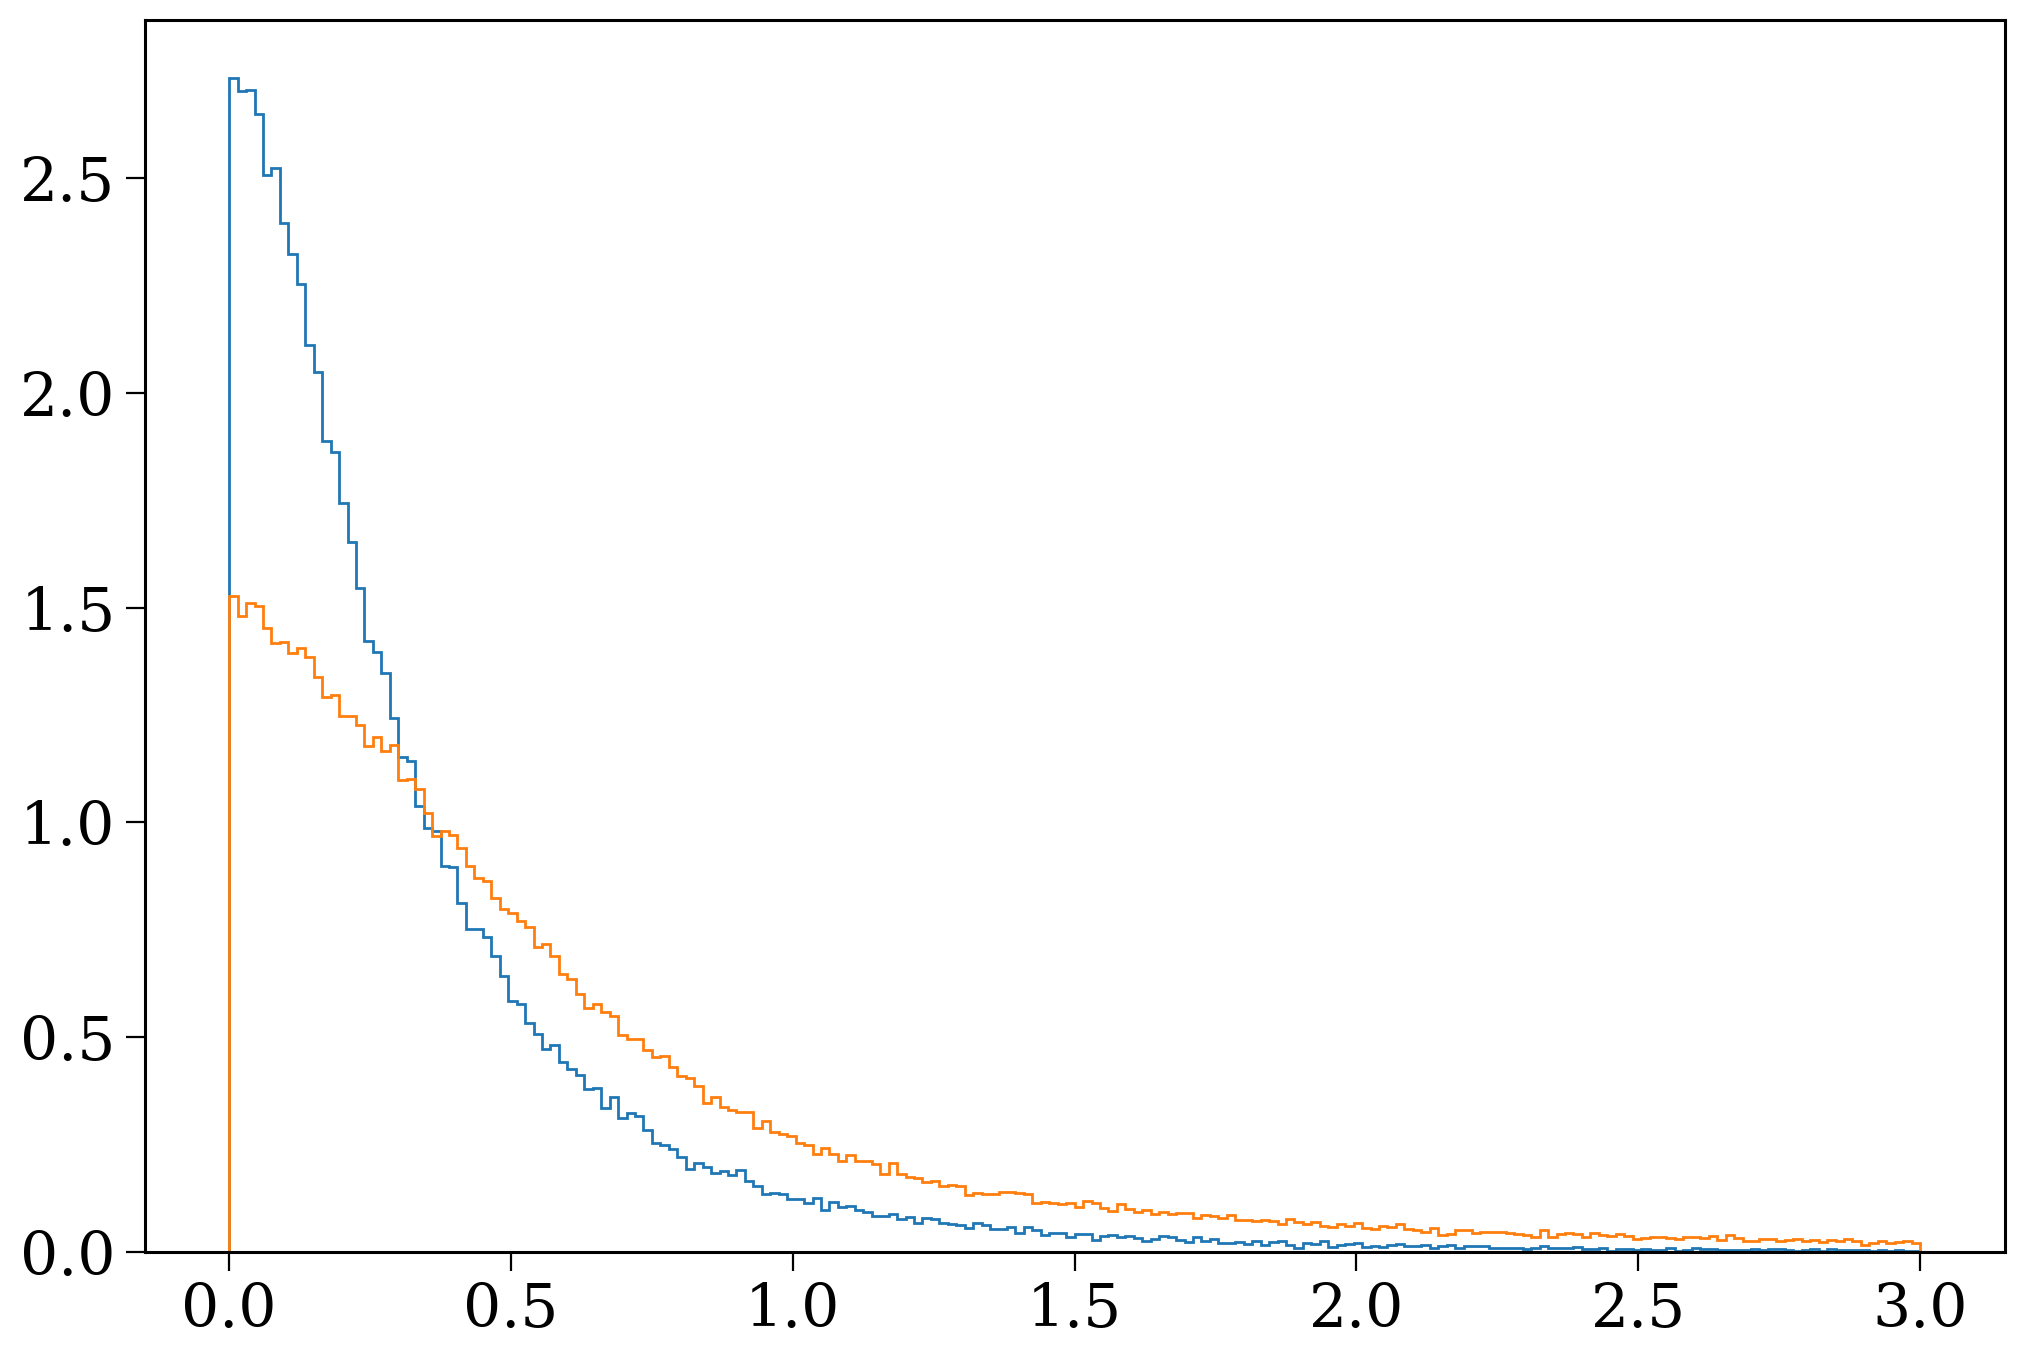

In [164]:
plt.hist(pop.initial_galaxy.z.value, bins=np.linspace(0, 3, 201), histtype='step', density=True)
plt.hist(thing.pz, bins=np.linspace(0, 3, 201), histtype='step', density=True)
plt.show()

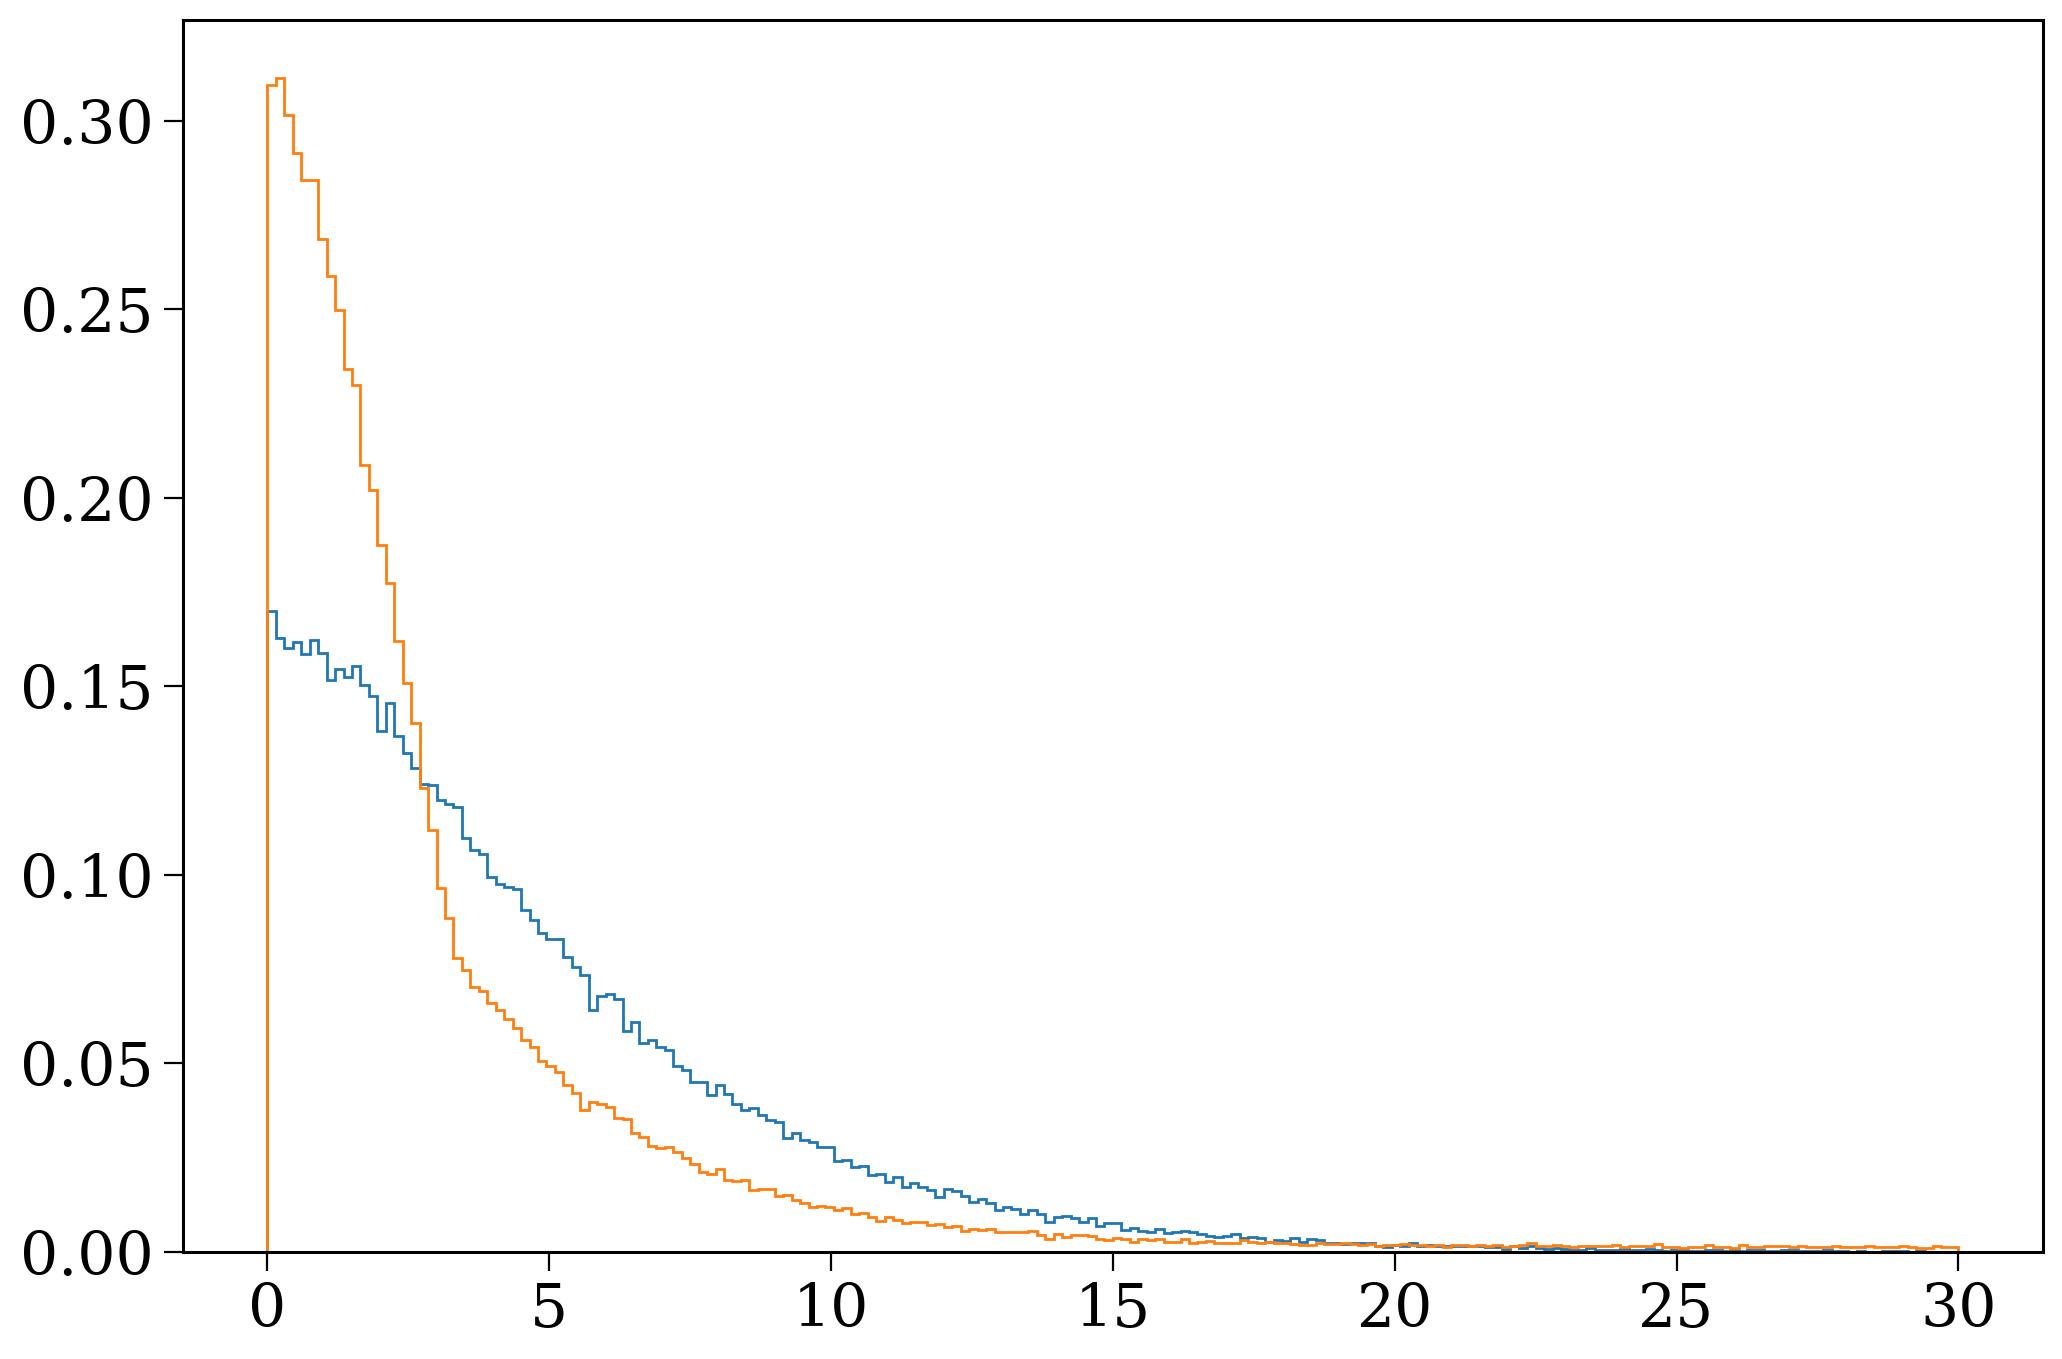

In [158]:
plt.hist(pop.initial_galaxy.x.value, bins=np.linspace(0, 30, 201), histtype='step', density=True)
plt.hist(thing.px, bins=np.linspace(0, 30, 201), histtype='step', density=True)
plt.show()

In [185]:
df = pd.read_csv("~/ceph/underworld/sweeney_data/kicked_remnants_igoshev_young_7.8_DC_integrated_final.csv")

9259


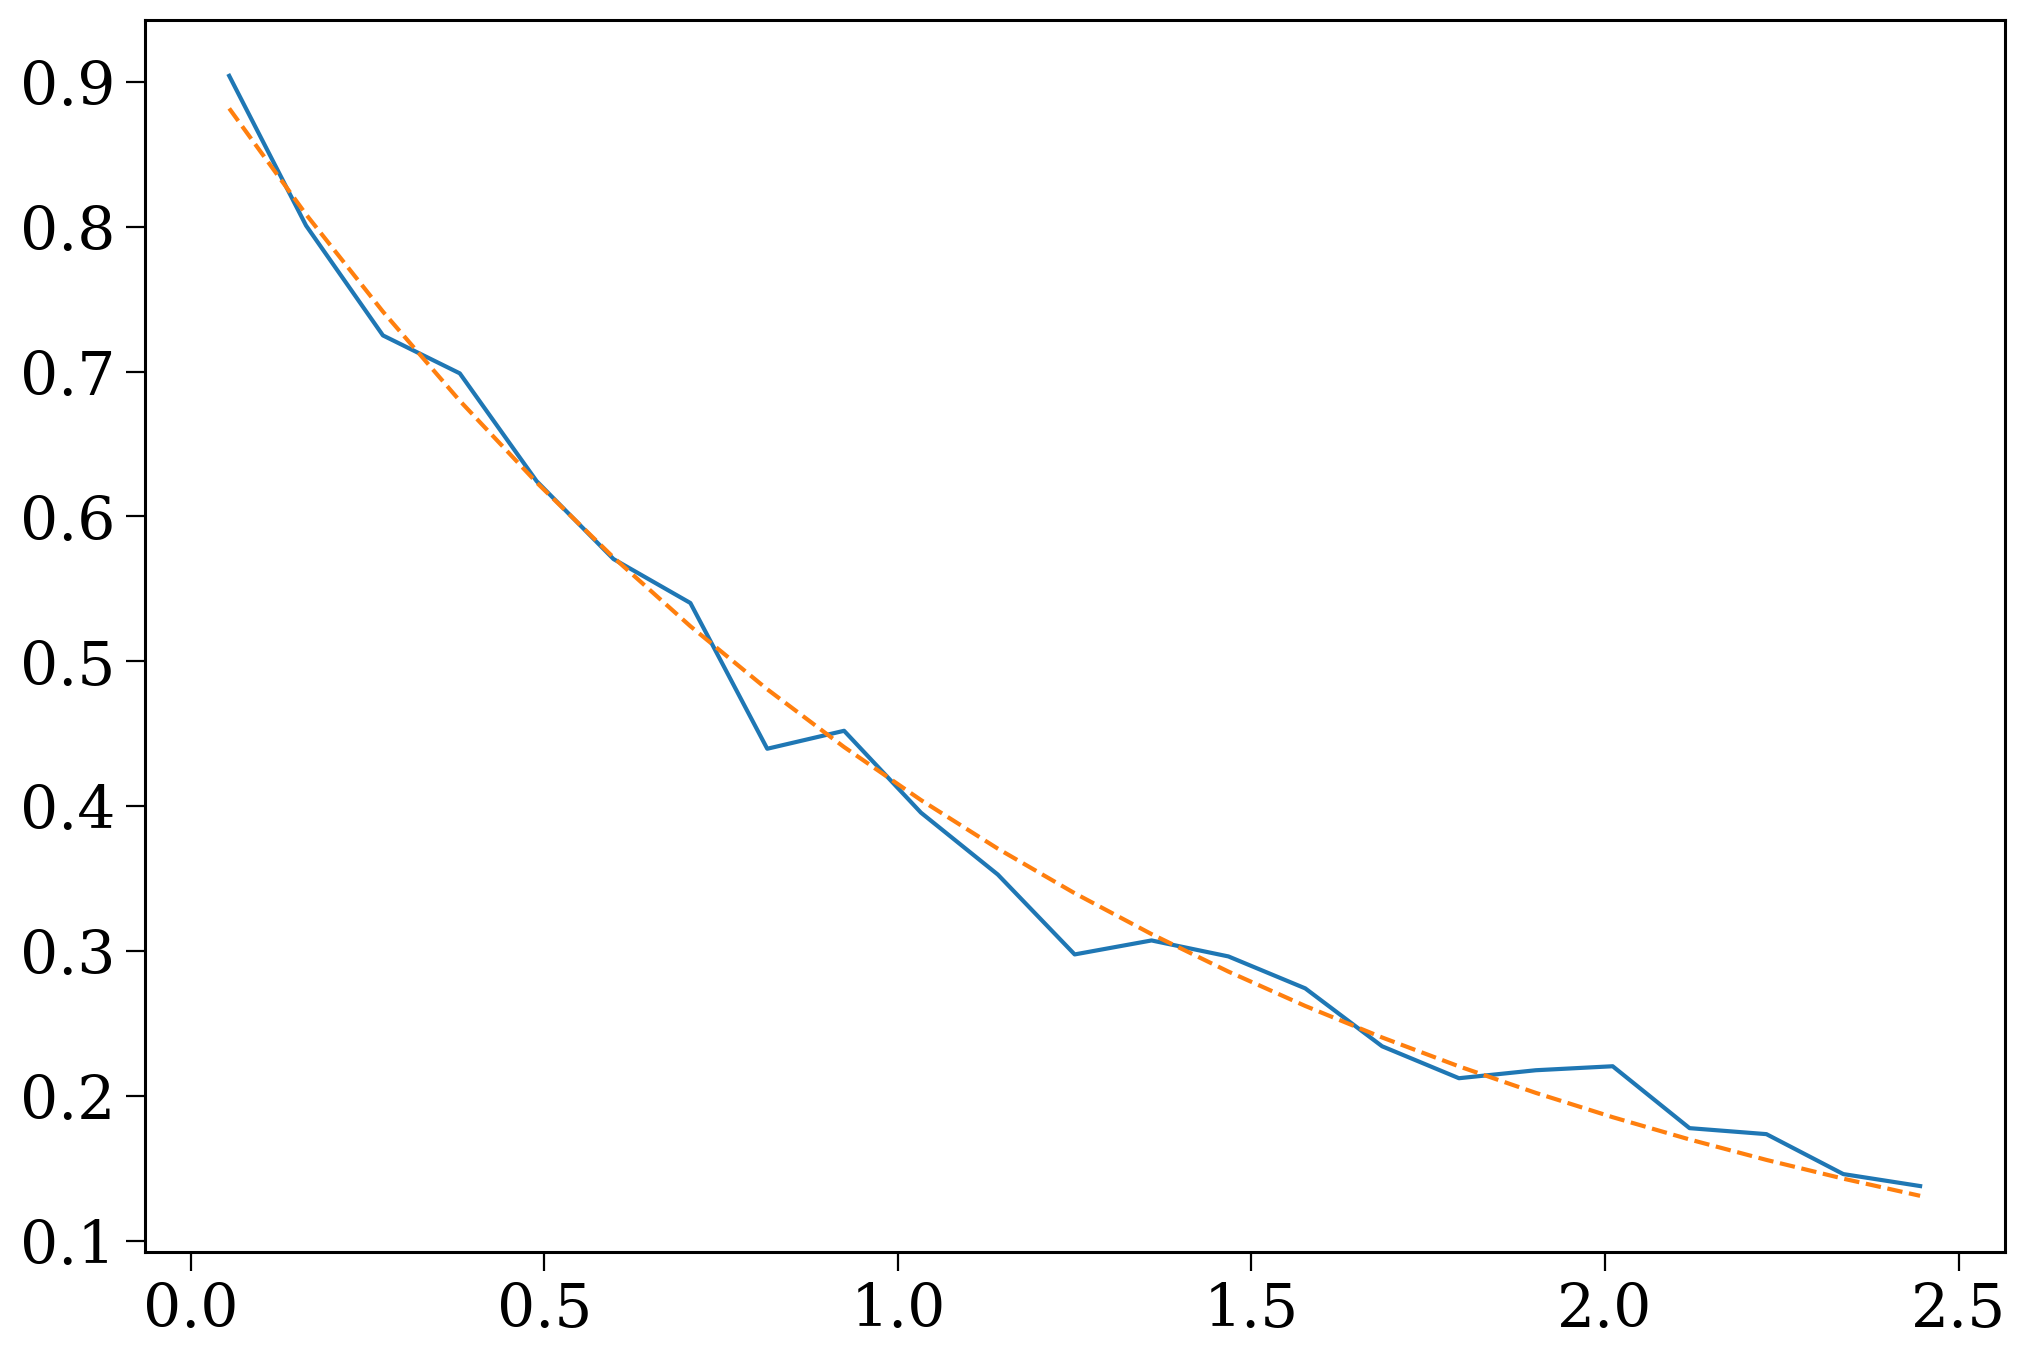

For the TEST, scale height = 1255 +/- 26 pc


In [190]:
def exponential(z, a, h):
    return a * np.exp(-np.abs(z) / h)

from scipy.optimize import curve_fit

name = "TEST"

z = df[(df["R"] > 7.5) & (df["R"] < 8.5)]["pz"]
# z = df["pz"]

print(len(z))

hist, bin_edges = np.histogram(np.abs(z), bins='auto', range=(0, 2.5), density=True)
bin_centres = [(bin_edges[i] + bin_edges[i+1])/2 for i in range(len(bin_edges)-1)]
pars, cov = curve_fit(f=exponential, xdata=bin_centres, ydata=hist,
                                        p0=[1, 1], bounds=(-np.inf, np.inf))
stdevs = np.sqrt(np.diag(cov))
if True:
    plt.figure()
    plt.plot(bin_centres, hist, label=name)
    plt.plot(bin_centres, exponential(np.array(bin_centres), pars[0], pars[1]), '--', label=name)
    plt.show()
print(f'For the {name}, scale height = {pars[1]*1e3:.0f} +/- {stdevs[1]*1e3:.0f} pc')

In [208]:
thing["comp"].value_counts()

comp
thick    171258
bulge    124435
halo      73752
thin      65435
Name: count, dtype: int64

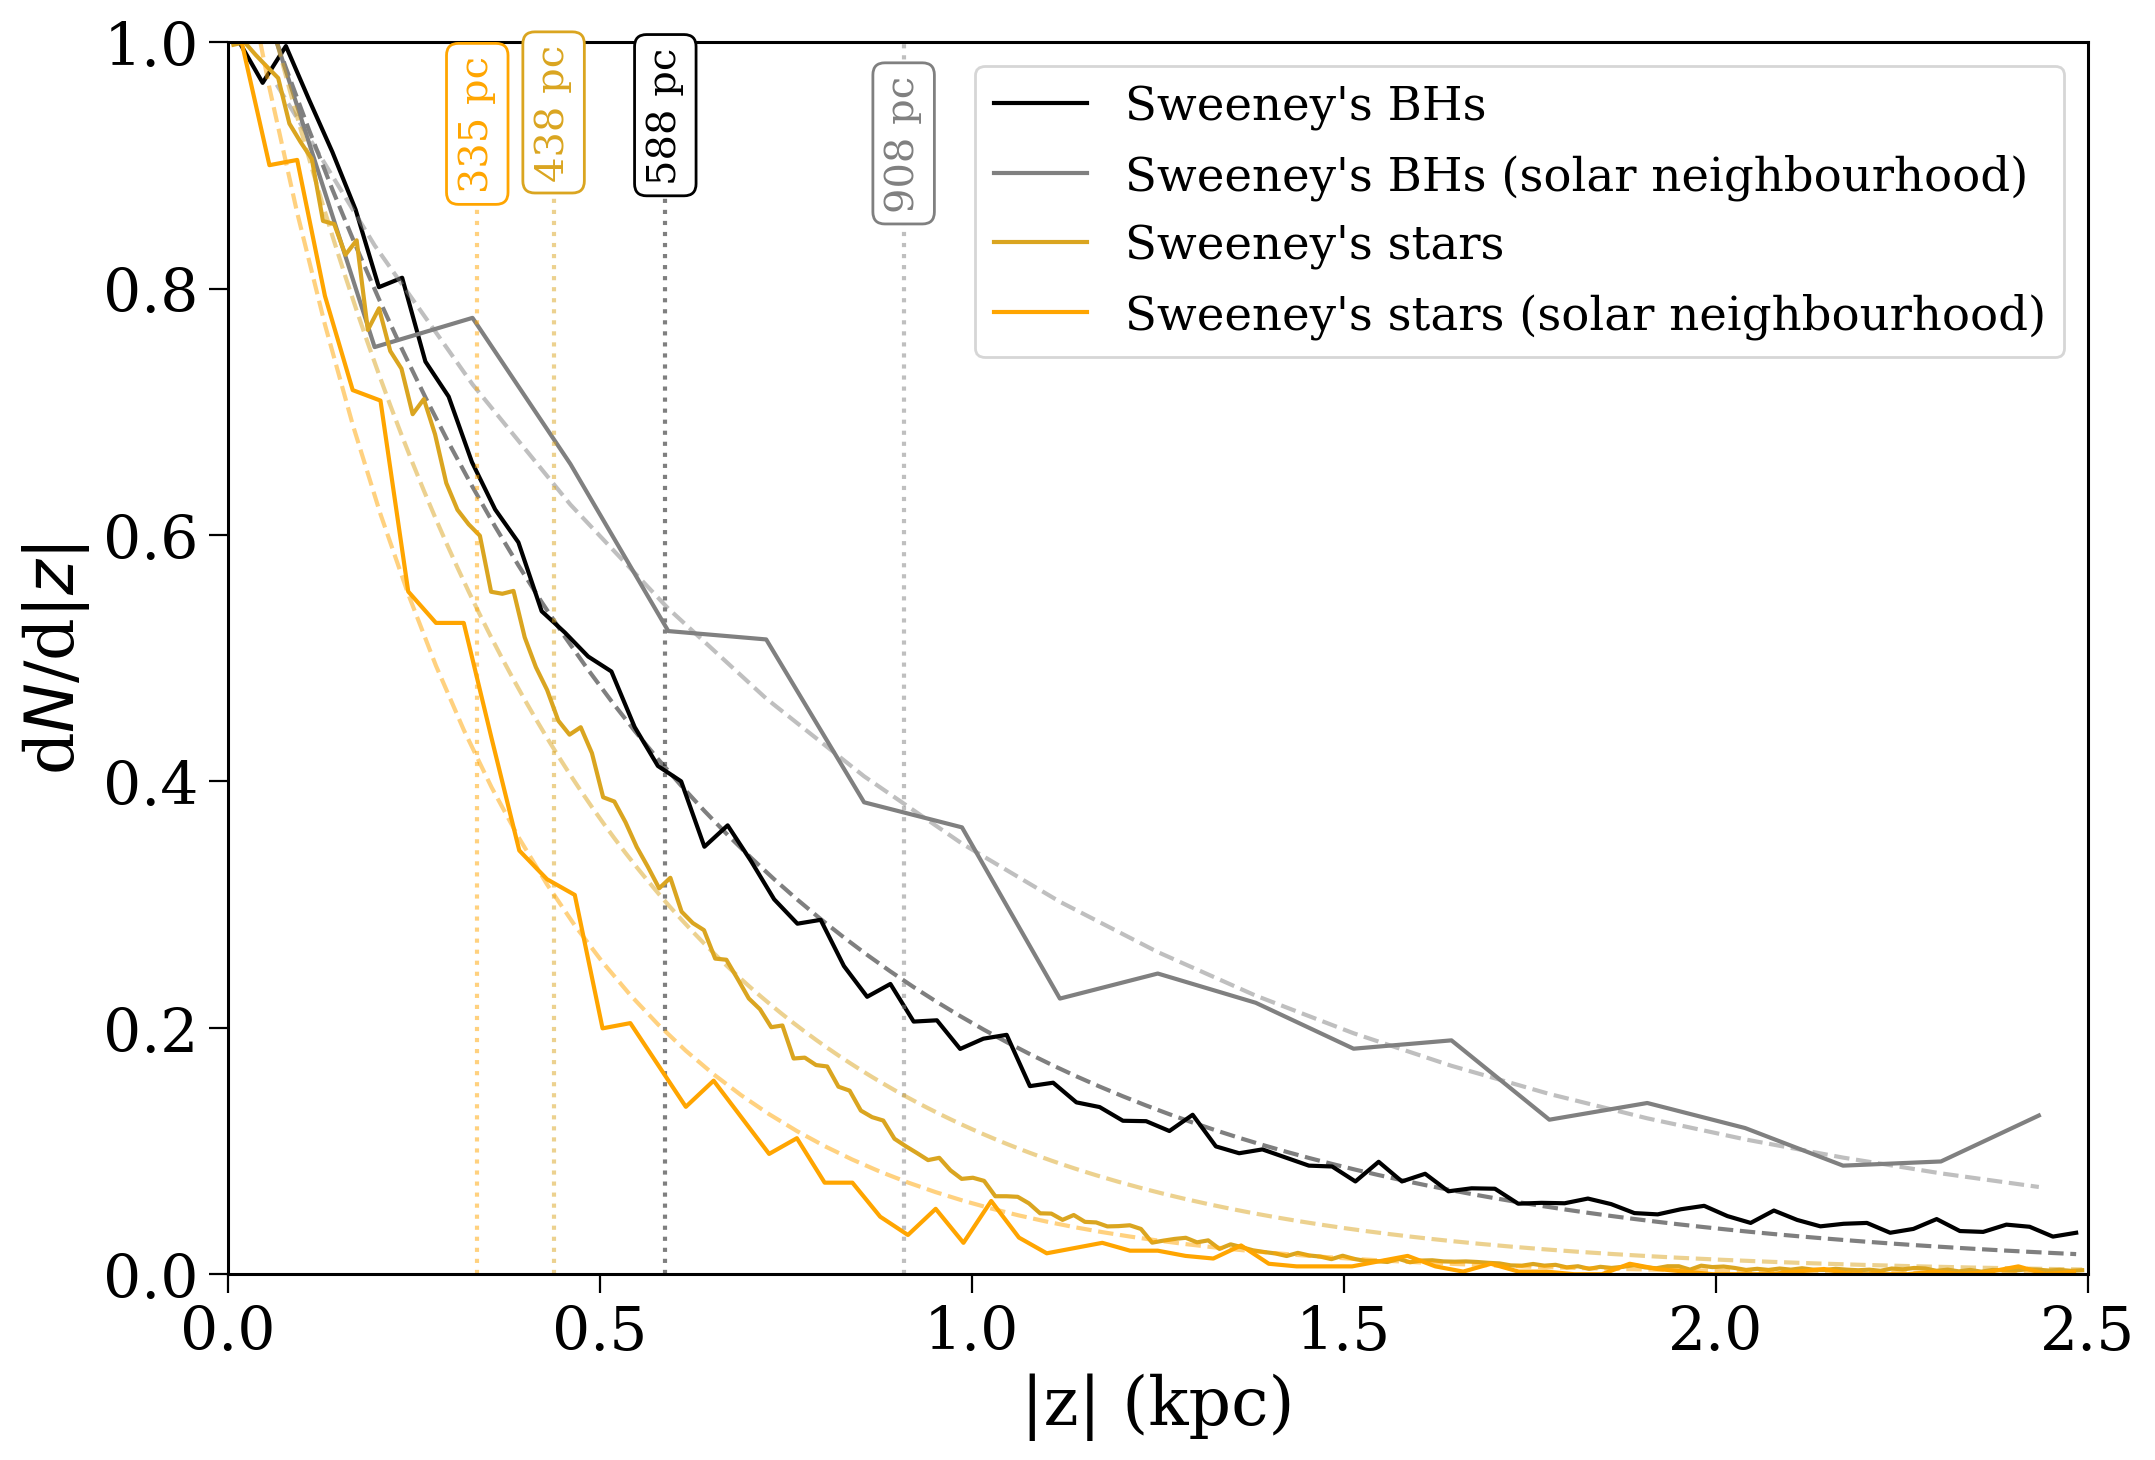

([np.float64(0.3353353353353353)],
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='|z| (kpc)', ylabel='d$N$/d$|z|$'>)

In [209]:
reload(plotting)

df_masked = df[df["rtype"] == "Black Hole"]
N = 1

_, fig, ax = plotting.estimate_scale_height(
    z=df_masked["pz"].values * u.kpc,
    plot=True,
    label="Sweeney's BHs",
    colour="black",
    xlim=(0, 2.5),
    bins="auto",
    ylim=(0, 1),
    n_components=N,
    show=False,
)


plotting.estimate_scale_height(
    z=df_masked["pz"].values * u.kpc,
    plot=True,
    label="Sweeney's BHs (solar neighbourhood)",
    colour="grey",
    xlim=(0, 2.5),
    ylim=(0, 1),
    bins="auto",
    n_components=N,
    R=df_masked["R"].values * u.kpc,
    Rlims=(7.5, 8.5),
    fig=fig,
    ax=ax,
    show=False,
)


plotting.estimate_scale_height(
    z=stars["pz"].values * u.kpc,
    plot=True,
    label="Sweeney's stars",
    colour="goldenrod",
    xlim=(0, 2.5),
    ylim=(0, 1),
    bins="auto",
    n_components=N,
    fig=fig,
    ax=ax,
    show=False,
)


plotting.estimate_scale_height(
    z=stars["pz"].values * u.kpc,
    plot=True,
    label="Sweeney's stars (solar neighbourhood)",
    colour="orange",
    xlim=(0, 2.5),
    ylim=(0, 1),
    bins="auto",
    n_components=N,
    R=stars["R"].values * u.kpc,
    Rlims=(7.5, 8.5),
    fig=fig,
    ax=ax,
)

In [5]:
import ebf

In [44]:
test = pd.read_hdf("~/ceph/underworld/sweeney_remnants_direct.h5")

In [51]:
test[test["rtype"] == "Black Hole"]

,px,py,pz,vx,vy,vz,age,smass,feh,popid,rtype,kick,kick_x,kick_y,kick_z,x_final,y_final,z_final,v_x_final,v_y_final,v_z_final
4,-9.237897,0.506340,0.009437,16.823822,231.885752,1.973024,0.067331,29.939665,-0.083976,0.0,Black Hole,6.090476,-4.795376,-2.385386,2.899688,0.535092,10.238521,-0.070365,207.990779,6.217259,-2.630606
8,-7.892731,-1.581735,0.079146,-36.089087,231.645959,-0.085893,0.027603,51.245354,0.064850,0.0,Black Hole,0.000000,0.000000,0.000000,0.000000,-6.635648,4.652232,-0.036997,122.405834,198.314065,-5.206408
20,-5.519245,-0.097401,0.008510,-3.600311,213.680912,-4.595726,0.030940,45.215714,0.122317,0.0,Black Hole,0.000000,0.000000,-0.000000,0.000000,-1.730559,4.873389,0.011289,220.486959,60.783397,4.651215
29,-5.528759,-1.282834,0.002379,-84.034407,209.394112,-0.572419,0.030502,29.983971,0.180150,0.0,Black Hole,122.174861,64.480504,24.375303,-100.870243,-2.450994,5.155308,-1.405499,188.808396,140.422131,20.292464
36,-5.279603,-1.395603,0.023850,-40.712977,230.575424,0.687103,0.035479,64.719521,0.206240,0.0,Black Hole,0.000000,-0.000000,0.000000,-0.000000,-1.263725,5.344597,-0.014830,221.063901,73.329587,2.286362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434855,3.640999,0.548664,-0.412118,15.695996,-275.323748,68.194229,10.000000,44.999336,0.062763,9.0,Black Hole,0.000000,0.000000,-0.000000,0.000000,-0.625198,6.179826,-0.213016,165.200873,-15.750755,-61.157316
434857,3.595645,-1.000418,0.219119,-20.432860,-362.012712,-2.428452,10.000000,48.515137,0.167372,9.0,Black Hole,0.000000,0.000000,0.000000,-0.000000,11.257646,2.709070,0.411801,117.028781,-89.278999,-5.508131
434858,3.728503,0.219750,0.184469,189.669962,-290.816362,97.437416,10.000000,25.663015,0.298754,9.0,Black Hole,124.227612,-111.284119,-18.780084,-51.919677,6.019570,6.486878,-0.579992,83.374933,-104.777198,10.553112
434875,3.832898,-0.169118,0.530988,-119.578513,7.255049,22.701304,10.000000,29.361975,-0.555231,9.0,Black Hole,25.648054,-1.838978,-1.366876,-25.545498,-1.204454,-3.864871,-0.424497,29.905716,94.272518,-38.158572


New thing 0.3483483483483483 [1.12860866 2.89457575]
0.34547377054368505


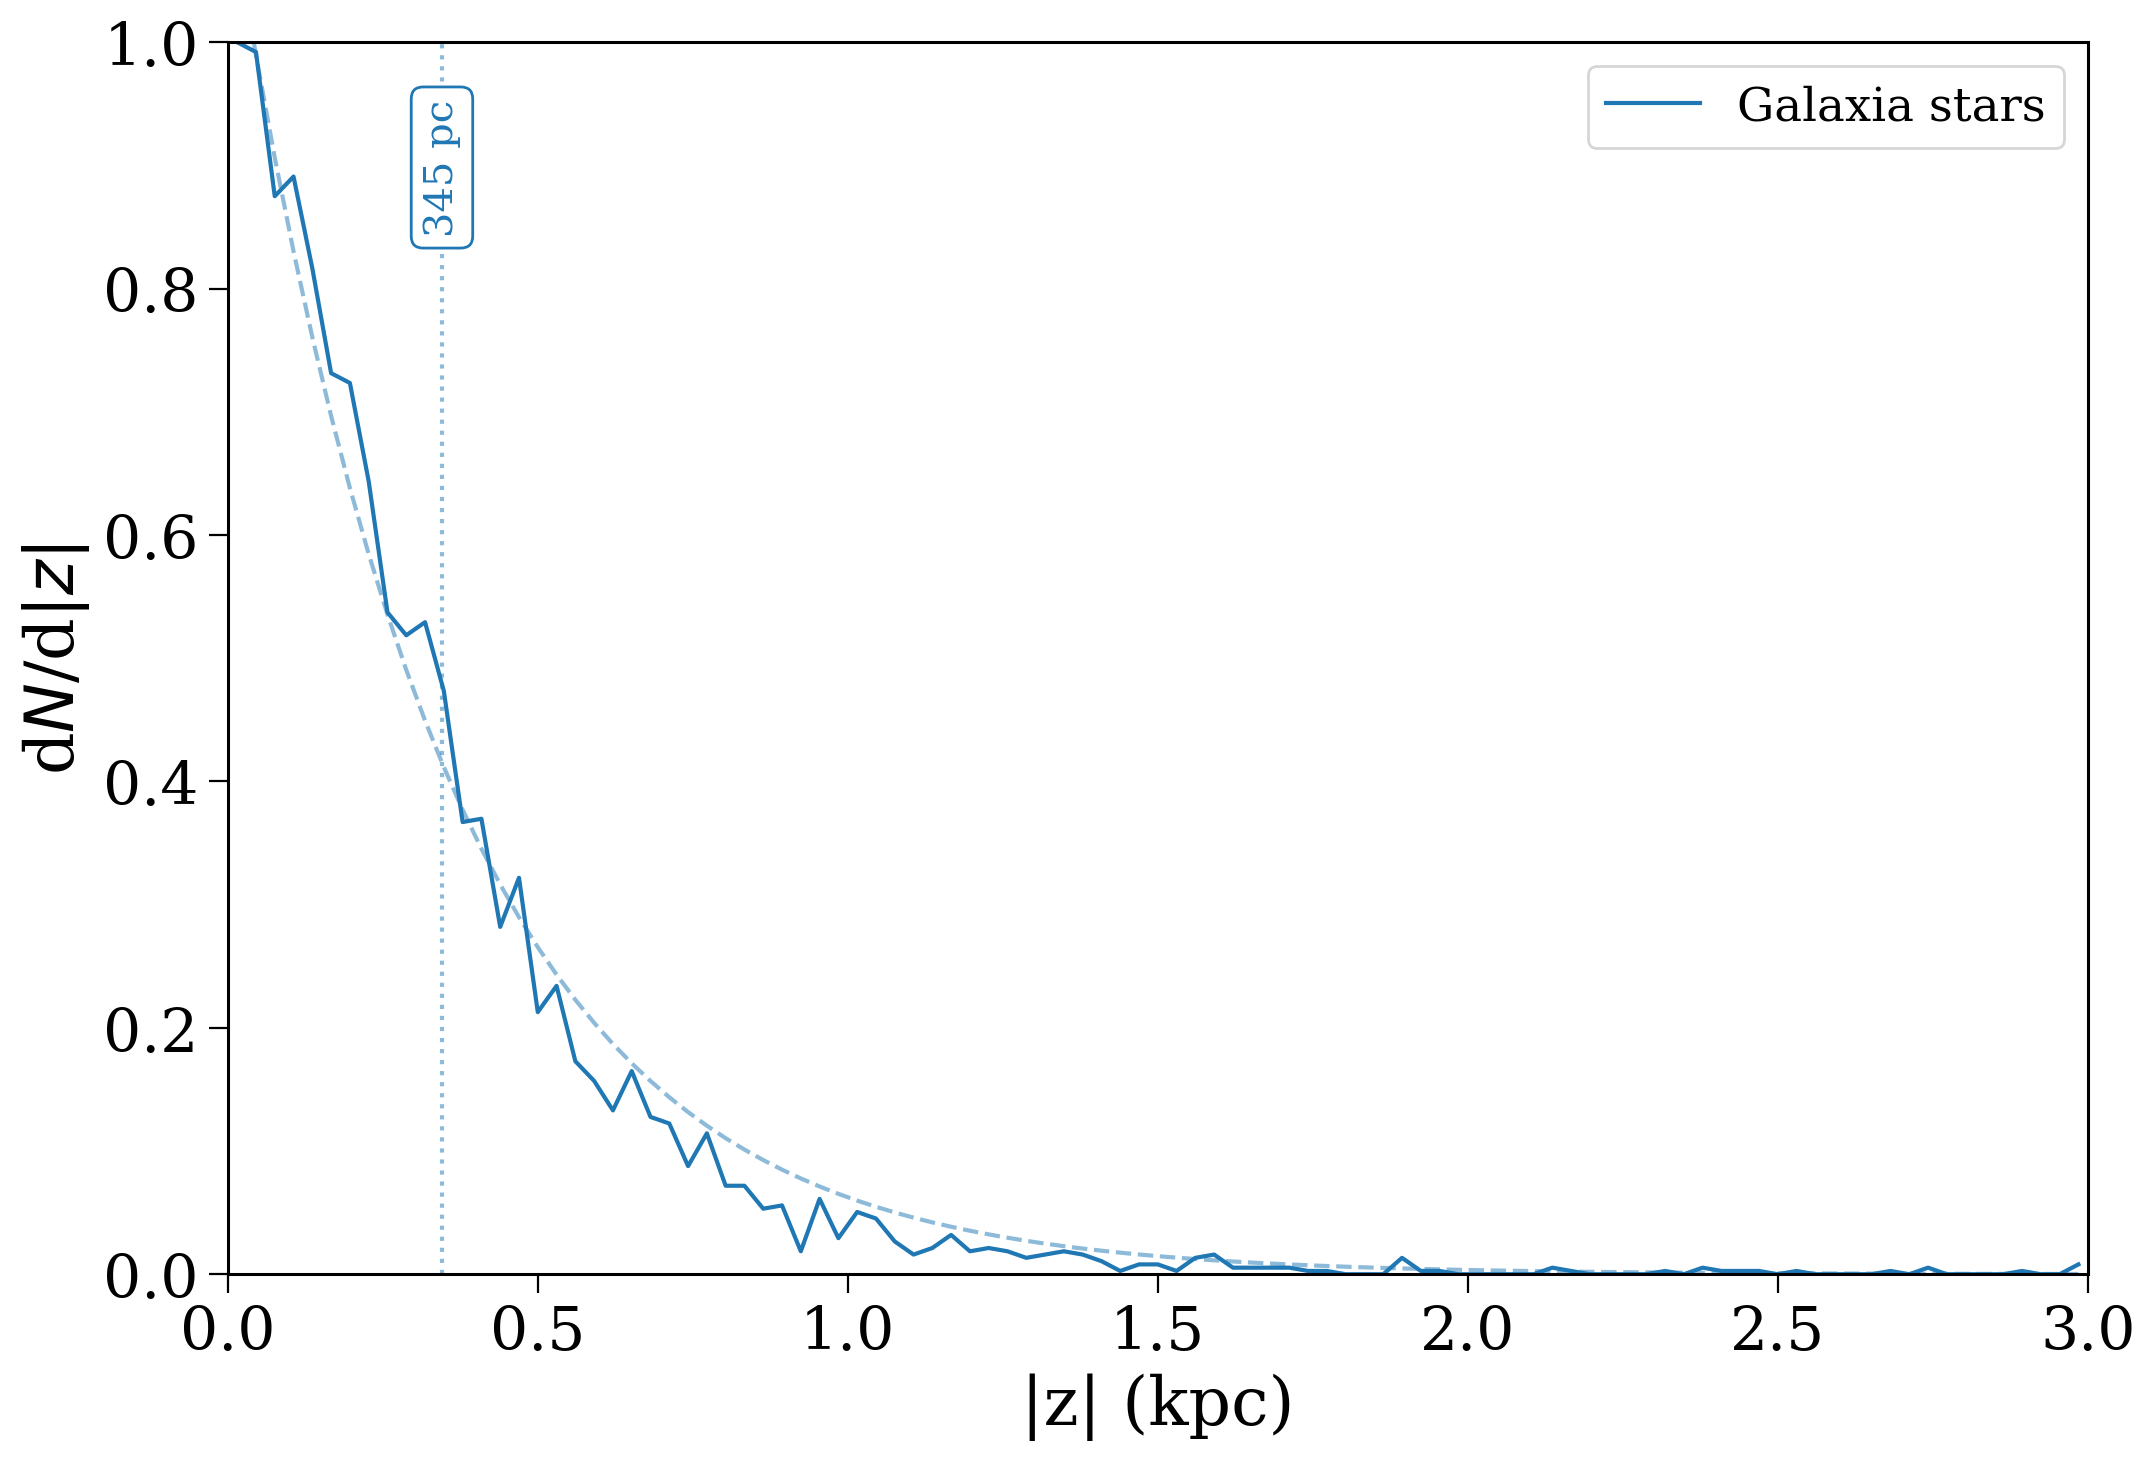

New thing 0.5735735735735735 [1.08752506 1.75000822]
0.5714258862626503


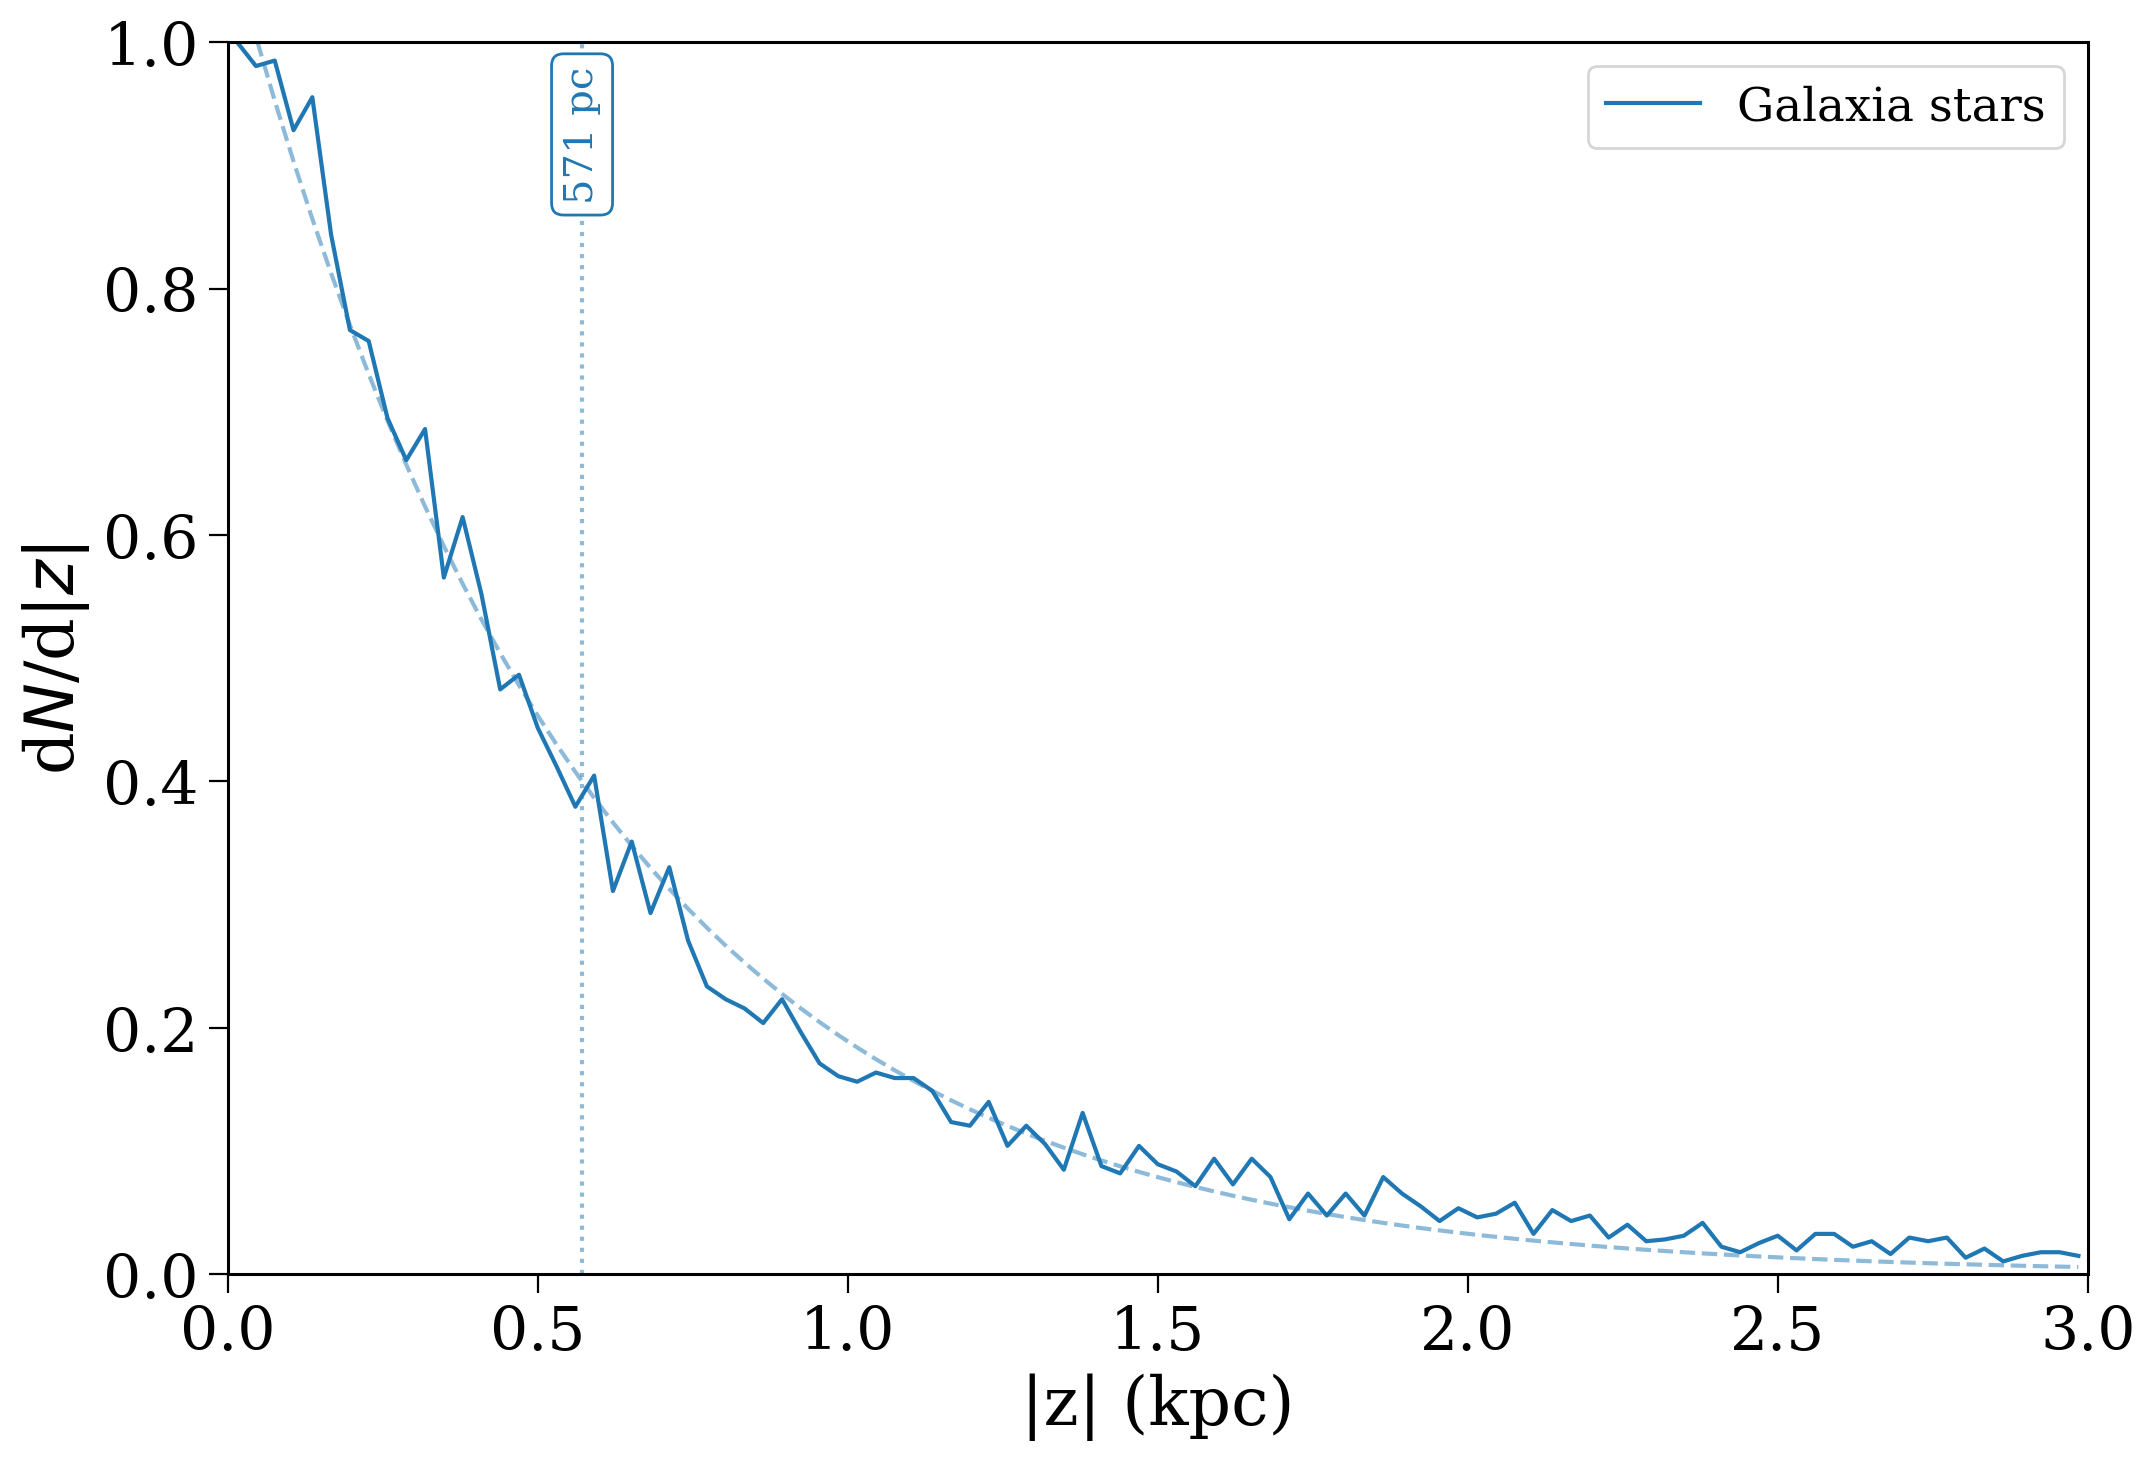

([np.float64(0.5714258862626503)],
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='|z| (kpc)', ylabel='d$N$/d$|z|$'>)

In [77]:
plotting.estimate_scale_height(
    z=stars[(stars["R"] > 7.5) & (stars["R"] < 8.5)]["pz"].values * u.kpc,
    plot=True,
    label="Galaxia stars",
    colour="tab:blue",
    show=True,
    bins=np.linspace(0, 3, 100),
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=1
)

plotting.estimate_scale_height(
    z=thing[(thing["R"] > 7.5) & (thing["R"] < 8.5)]["pz"].values * u.kpc,
    plot=True,
    label="Galaxia stars",
    colour="tab:blue",
    show=True,
    bins=np.linspace(0, 3, 100),
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=1
)

In [87]:
47/31

1.5161290322580645

In [88]:
900/334

2.694610778443114

In [89]:
965/345

2.7971014492753623

New thing 0.9669669669669669 [0.92497517 1.03669089]
0.9646076861256189
New thing 1.5045045045045045 [0.95202897 0.66579595]
1.5019616691238908
New thing 1.2822822822822824 [0.96986644 0.78060271]
1.2810614065141246


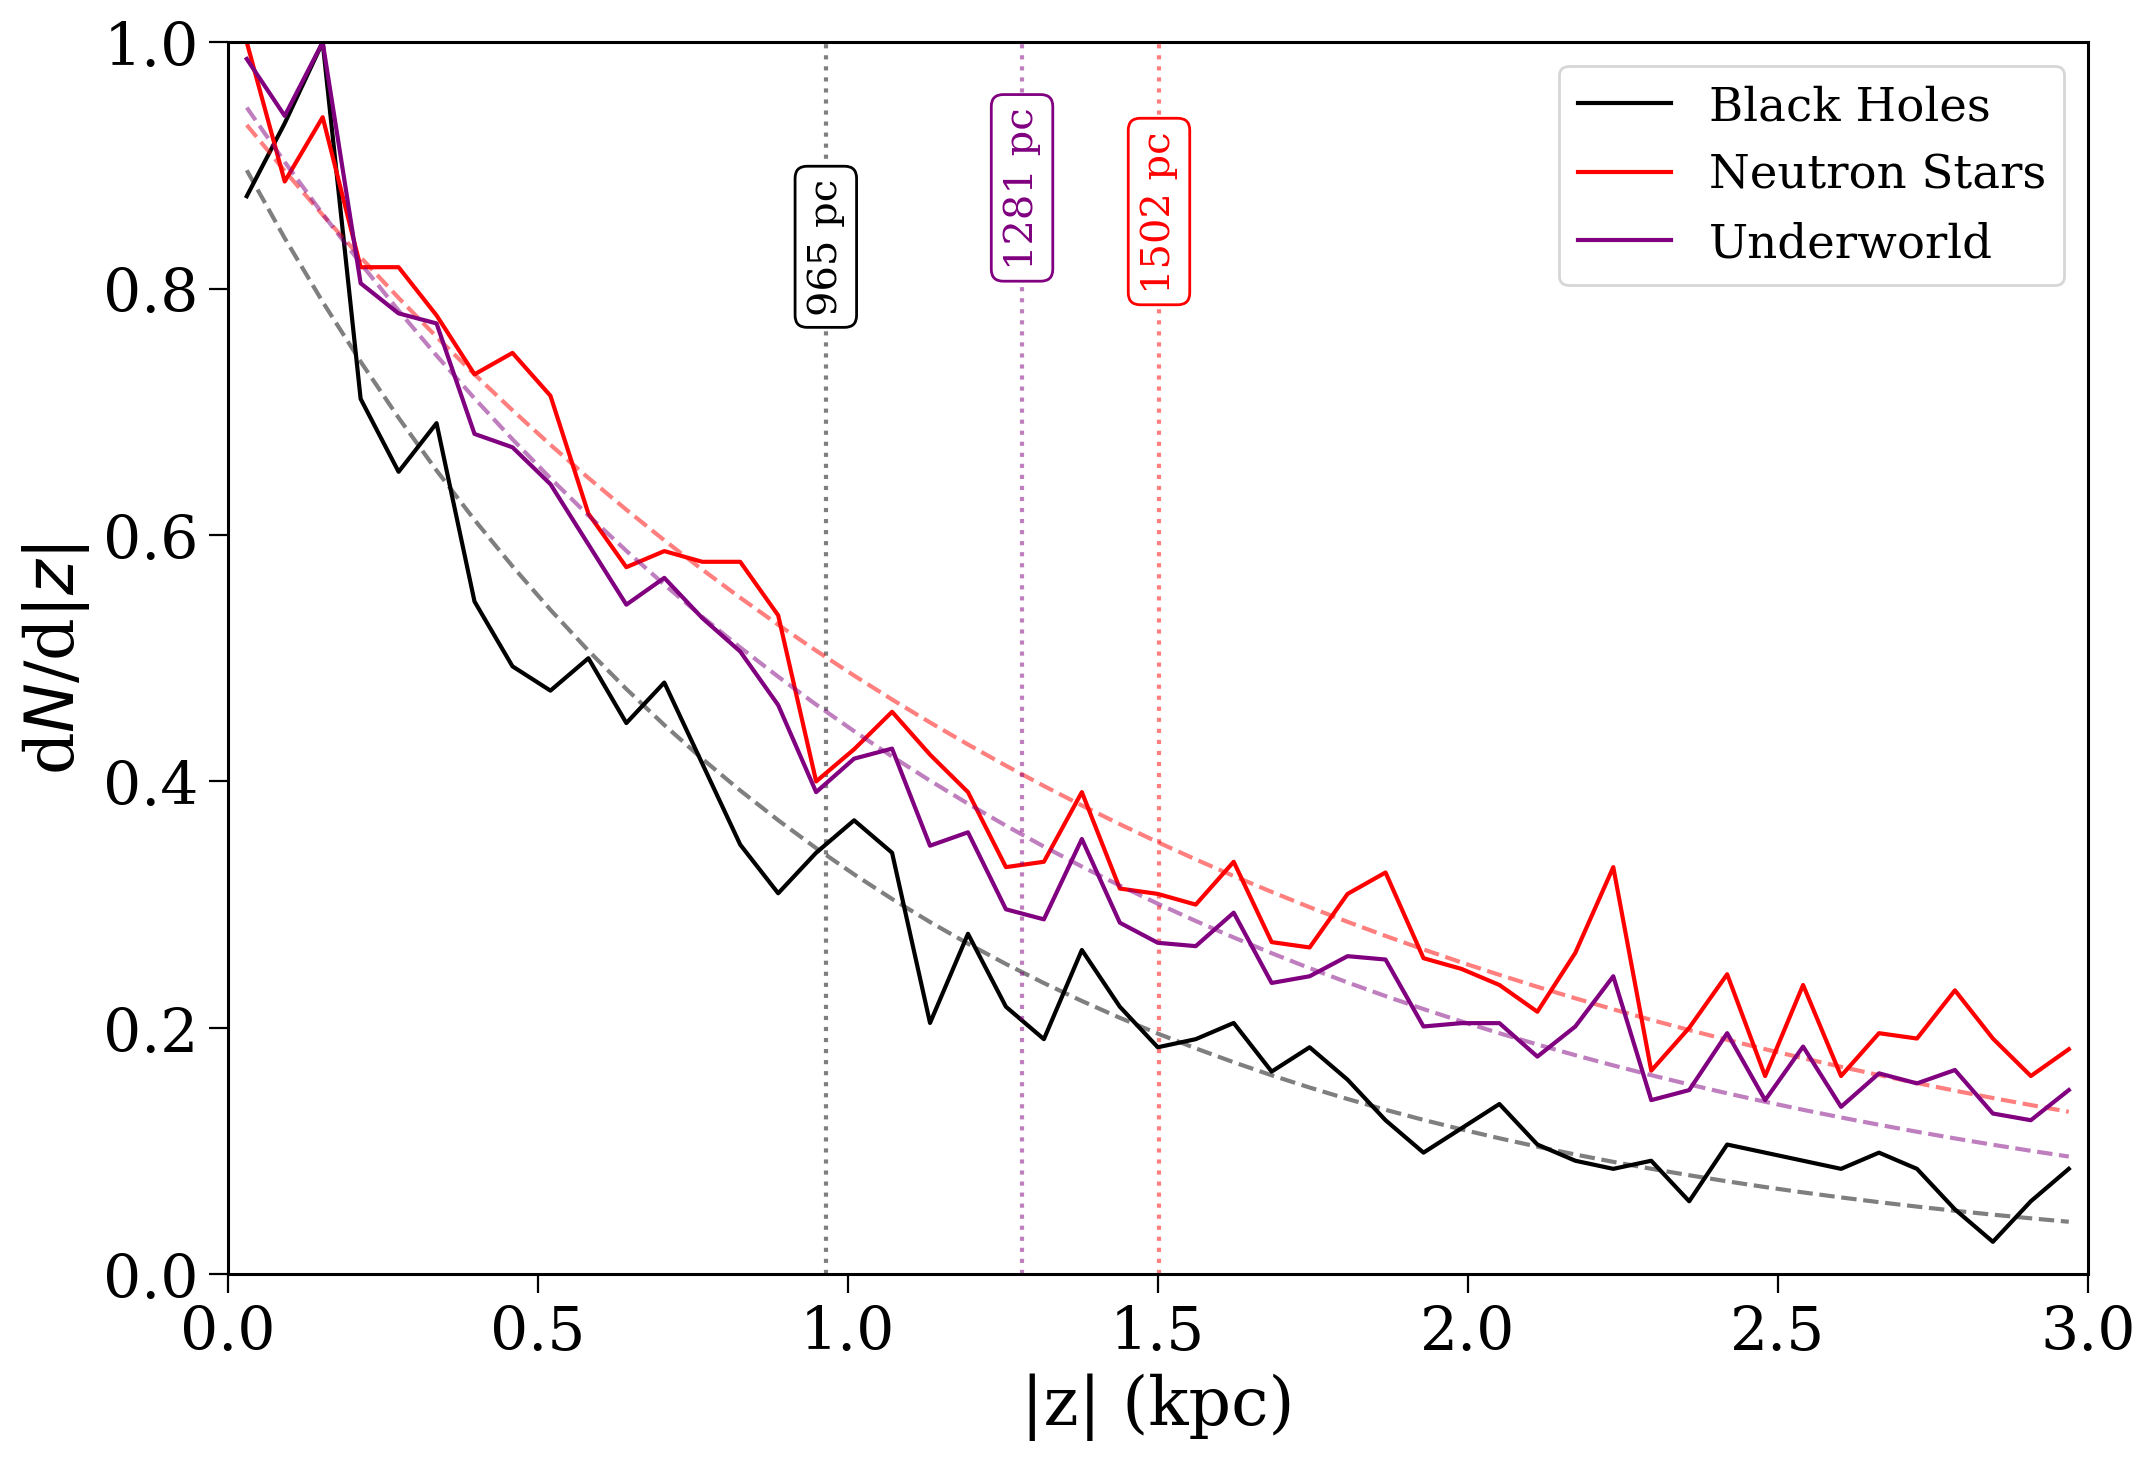

In [86]:
fig, ax = plt.subplots()

test["R_final"] = np.sqrt(test["x_final"]**2 + test["y_final"]**2)
mask = (test["R_final"] > 7.5) & (test["R_final"] < 8.5)

for rtype, l, c in zip(["Black Hole", "Neutron Star", None], 
                       ["Black Holes", "Neutron Stars", "Underworld"], 
                       ["black", "red", "purple"]):
    if rtype is not None:
        z_values = test[mask & (test["rtype"] == rtype)]["z_final"].values * u.kpc
    else:
        z_values = test[mask]["z_final"].values * u.kpc

    plotting.estimate_scale_height(
        z=z_values,
        plot=True,
        bins=np.linspace(0, 3, 50),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=1,
        fig=fig,
        ax=ax,
        show=False,
        label=l,
        colour=c
    )